# River Basin Land Use Change Analysis
## Using Google Earth Engine Dynamic World

This notebook analyzes land use changes in a river basin using:
- Dynamic World land cover classification
- Split map visualization for comparing two years
- Quantitative land use change statistics

---

# SECTION 0: USER CONFIGURATION (Edit This Per Basin)
**Edit this section for each new basin analysis.**

In [ ]:
import os

# ============================================================
# USER CONFIGURATION - Edit this section for each basin
# ============================================================

# Basin directory (contains input/ and output/ subdirectories)
BASIN_DIR = "Sio"

# Basin identification (used for cache directory and output files)
# Input/Output directory paths (derived from BASIN_DIR)
INPUT_DIR = os.path.join(BASIN_DIR, "input")
OUTPUT_DIR = os.path.join(BASIN_DIR, "output")

# Shapefile paths (relative to INPUT_DIR)
SHAPEFILE_PATH = os.path.join(INPUT_DIR, "sio-basin.shp")           # Basin boundary
RIVER_SHAPEFILE_PATH = os.path.join(INPUT_DIR, "sio-river.shp")  # River network
WETLAND_LAYERS = [                                                                                                                                                                                                       
      {'path': os.path.join(INPUT_DIR, "sio-wetlands-osm-merged.shp"), 'label': 'Wetland', 'color': '#008080'}                                                                                                          
    #   {'path': os.path.join(INPUT_DIR, "mara-wetland-2024.shp"), 'label': '2024 Wetland', 'color': '#800000'},                                                                                                             
  ]   

# Years to compare
YEAR_1 = 2015
YEAR_2 = 2025

# Map settings
ZOOM = 9  # Default zoom level for HTML maps

# Styling
BASIN_COLOR = '#000000'   # Basin boundary color
RIVER_COLOR = '#0000CD'   # River color (Medium blue)

# Additional features (basin-specific overlays)
# Set to [] if no additional features for this basin
ADDITIONAL_FEATURES = [
    # Example: Gold mines for Mara basin
    # {
    #     'path': os.path.join(INPUT_DIR, 'mara_gold_mines.geojson'),
    #     'name': 'Gold Mines',
    #     'color': '#FFD700',
    #     'type': 'point',
    #     'size': 10
    # },
    # Example: Wetlands
    # {
    #     'path': os.path.join(INPUT_DIR, 'wetlands.geojson'),
    #     'name': 'Wetlands',
    #     'color': '#00CED1',
    #     'type': 'polygon',
    #     'fill_opacity': 0.3
    # },
]

# Wetland cluster shapefiles (for 3D visualization)
# Set to None if not available for this basin

# Tile download zoom levels (for offline HTML)
TILE_ZOOM_LEVELS = [8, 9, 10, 11, 12]

# Countries for trans-boundary basin (WorldPop is organized by country)
COUNTRIES = ['KEN', 'UGA']  # ISO3 codes: Kenya and Tanzania

# CHIRPS rainfall file path (after downloading from Google Drive)
RAINFALL_FILE = os.path.join(INPUT_DIR, "chirps_annual_avg_2000_2025.tif")

# Land cover raster files (after downloading from Google Drive)
# Set to None to skip loading, or provide path after downloading from Drive
LANDCOVER_YEAR1_FILE = os.path.join(INPUT_DIR, "landcover_2015.tif")
LANDCOVER_YEAR2_FILE = os.path.join(INPUT_DIR, "landcover_2025.tif")

# Landsat comparison years (may differ from Dynamic World years)
LANDSAT_YEAR_1 = 2000
LANDSAT_YEAR_2 = 2025

# ============================================================
# END USER CONFIGURATION
# ============================================================

os.makedirs(INPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Comparing years: {YEAR_1} vs {YEAR_2}")
print(f"Input directory: {INPUT_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Comparing years: 2015 vs 2025
Input directory: Sio/input
Output directory: Sio/output


---
# SECTION 1: SETUP & IMPORTS (Do Not Edit)
Core imports, Earth Engine initialization, and helper functions.

In [77]:
# Core imports
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import os
import json
import requests
import rasterio
from rasterio.io import MemoryFile
from rasterio.features import geometry_mask
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
import zipfile
from io import BytesIO
import base64
import shapely.geometry
from pathlib import Path
from IPython.display import HTML, display, IFrame

# Initialize Earth Engine
ee.Initialize()

print("Earth Engine initialized successfully!")

Earth Engine initialized successfully!


In [78]:
# Dynamic World class names and colors
DW_CLASSES = {
    0: {'name': 'Water', 'color': '#419BDF'},
    1: {'name': 'Trees', 'color': '#397D49'},
    2: {'name': 'Grass', 'color': '#88B053'},
    3: {'name': 'Flooded Vegetation', 'color': '#7A87C6'},
    4: {'name': 'Crops', 'color': '#E49635'},
    5: {'name': 'Shrub & Scrub', 'color': '#DFC35A'},
    6: {'name': 'Built Area', 'color': '#C4281B'},
    7: {'name': 'Bare Ground', 'color': '#A59B8F'},
    8: {'name': 'Snow & Ice', 'color': '#B39FE1'}
}

# Dynamic World class colors (RGB) for 3D visualization
DW_COLORS = {
    0: [65, 155, 223],   # Water - #419BDF
    1: [57, 125, 73],    # Trees - #397D49
    2: [136, 176, 83],   # Grass - #88B053
    3: [122, 135, 198],  # Flooded Vegetation - #7A87C6
    4: [228, 150, 53],   # Crops - #E49635
    5: [223, 195, 90],   # Shrub & Scrub - #DFC35A
    6: [196, 40, 27],    # Built Area - #C4281B
    7: [165, 155, 143],  # Bare Ground - #A59B8F
    8: [179, 159, 225],  # Snow & Ice - #B39FE1
}

# Legend labels and colors
legend_labels = [v['name'] for v in DW_CLASSES.values()]
legend_colors = [v['color'] for v in DW_CLASSES.values()]

# Visualization parameters for Dynamic World
dw_vis = {
    'min': 0,
    'max': 8,
    'palette': [v['color'] for v in DW_CLASSES.values()]
}

print(f"Dynamic World classes defined: {len(DW_CLASSES)} classes")

Dynamic World classes defined: 9 classes


In [79]:
# Cache helper functions
def get_cache_dir():
    """Get the output directory for a basin."""
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    return OUTPUT_DIR

def get_raster_dir():
    """Get the raster cache directory for a basin."""
    raster_dir = os.path.join(OUTPUT_DIR, "rasters")
    os.makedirs(raster_dir, exist_ok=True)
    return raster_dir

def get_tiles_dir():
    """Get the tiles directory for a basin."""
    tiles_dir = os.path.join(OUTPUT_DIR, "tiles")
    os.makedirs(tiles_dir, exist_ok=True)
    return tiles_dir

def cache_exists(filename):
    """Check if a cached file exists."""
    filepath = os.path.join(OUTPUT_DIR, filename)
    return os.path.exists(filepath)

def raster_cache_exists(filename):
    """Check if a cached raster file exists."""
    filepath = os.path.join(get_raster_dir(), filename)
    return os.path.exists(filepath)

def load_cached_raster(filename):
    """Load a cached raster file."""
    filepath = os.path.join(get_raster_dir(), filename)
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Run download cells first: {filepath}")
    return np.load(filepath)

def save_cached_raster(filename, data):
    """Save a raster to cache."""
    filepath = os.path.join(get_raster_dir(), filename)
    np.save(filepath, data)
    print(f"Saved to cache: {filepath}")

def load_additional_feature(feature_config, basin_geometry):
    """
    Load a feature from GeoJSON or shapefile and convert to Earth Engine.
    Clips to basin boundary.
    """
    path = feature_config['path']
    
    # Load based on file extension
    if path.endswith('.geojson') or path.endswith('.json'):
        gdf = gpd.read_file(path)
    elif path.endswith('.shp'):
        gdf = geemap.shp_to_gdf(path)
    else:
        raise ValueError(f"Unsupported file format: {path}")
    
    # Convert to Earth Engine
    ee_feature = geemap.gdf_to_ee(gdf)
    
    # Clip to basin if it's a polygon or line type
    if feature_config.get('type') in ['polygon', 'line']:
        def clip_feature(f):
            return f.intersection(basin_geometry, ee.ErrorMargin(1))
        ee_feature = ee_feature.map(clip_feature)
    
    return {
        'ee': ee_feature,
        'gdf': gdf,
        **feature_config
    }

print("Helper functions defined.")

Helper functions defined.


---
# SECTION 2: DATA DOWNLOADS (Run Once Per Basin)
Download and cache all data. Run this section once per basin, then skip on subsequent runs.

**Note:** After running these cells, data is cached to `./data/{BASIN_DIR}/`

In [6]:
# Download tiles for offline use
import math
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm

def deg2num(lat_deg, lon_deg, zoom):
    """Convert lat/lon to tile numbers"""
    lat_rad = math.radians(lat_deg)
    n = 2.0 ** zoom
    xtile = int((lon_deg + 180.0) / 360.0 * n)
    ytile = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    return (xtile, ytile)

def download_tile(args):
    """Download a single tile"""
    url, save_path = args
    try:
        if os.path.exists(save_path):
            return True, save_path
        
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        }
        response = requests.get(url, timeout=30, headers=headers)
        if response.status_code == 200:
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            with open(save_path, 'wb') as f:
                f.write(response.content)
            return True, save_path
        return False, f"HTTP {response.status_code}"
    except Exception as e:
        return False, str(e)

def download_tiles_for_bounds(tile_url_template, bounds, zoom_levels, output_dir, name):
    """Download all tiles within bounds for specified zoom levels"""
    min_lat, min_lon, max_lat, max_lon = bounds
    
    tiles_to_download = []
    for zoom in zoom_levels:
        min_tile = deg2num(max_lat, min_lon, zoom)  # Note: max_lat gives min y tile
        max_tile = deg2num(min_lat, max_lon, zoom)
        
        for x in range(min_tile[0], max_tile[0] + 1):
            for y in range(min_tile[1], max_tile[1] + 1):
                url = tile_url_template.replace('{z}', str(zoom)).replace('{x}', str(x)).replace('{y}', str(y))
                save_path = os.path.join(output_dir, name, str(zoom), str(x), f"{y}.png")
                tiles_to_download.append((url, save_path))
    
    print(f"Downloading {len(tiles_to_download)} tiles for {name}...")
    
    success_count = 0
    with ThreadPoolExecutor(max_workers=10) as executor:
        futures = {executor.submit(download_tile, args): args for args in tiles_to_download}
        for future in tqdm(as_completed(futures), total=len(tiles_to_download), desc=name):
            success, result = future.result()
            if success:
                success_count += 1
    
    print(f"Downloaded {success_count}/{len(tiles_to_download)} tiles for {name}")
    return success_count

def get_ee_tile_url(image, vis_params):
    """Get Earth Engine tile URL for an image"""
    map_id = image.getMapId(vis_params)
    return map_id['tile_fetcher'].url_format

def download_lc_raster(lc_image, year, roi, output_dir, scale=200, max_retries=3):
    """Download land cover as GeoTIFF raster with retry logic"""
    raster_path = os.path.join(output_dir, f"landcover_{year}_raster.npy")
    
    if os.path.exists(raster_path):
        print(f"  Land cover {year} raster already exists: {raster_path}")
        return raster_path
    
    import time
    
    lc_download_url = lc_image.getDownloadURL({
        'scale': scale,  # Use coarser scale for faster download
        'crs': 'EPSG:4326',
        'region': roi,
        'format': 'GEO_TIFF'
    })
    
    # Retry logic with exponential backoff
    for attempt in range(max_retries):
        try:
            print(f"  Downloading land cover {year} (attempt {attempt + 1}/{max_retries})...")
            response = requests.get(lc_download_url, timeout=300)  # 5 minute timeout
            response.raise_for_status()
            content = response.content
            break
        except requests.exceptions.Timeout:
            if attempt < max_retries - 1:
                wait_time = 30 * (attempt + 1)
                print(f"  Timeout, waiting {wait_time}s before retry...")
                time.sleep(wait_time)
            else:
                raise
    
    # Parse the response
    if content[:2] == b'PK':
        with zipfile.ZipFile(BytesIO(content)) as zf:
            tif_name = [n for n in zf.namelist() if n.endswith('.tif')][0]
            tif_data = zf.read(tif_name)
    elif content[:4] in [b'II\x2a\x00', b'MM\x00\x2a']:
        tif_data = content
    else:
        raise ValueError(f"Could not parse Land Cover {year} response")
    
    with MemoryFile(tif_data) as memfile:
        with memfile.open() as src:
            lc_data = src.read(1)
    
    # Save as numpy array
    os.makedirs(output_dir, exist_ok=True)
    np.save(raster_path, lc_data)
    print(f"  Saved land cover {year} raster: {raster_path} ({lc_data.shape})")
    return raster_path

print("Download helper functions defined.")

Download helper functions defined.


In [7]:
# Download Dynamic World tiles + raster cache
# Skip if already cached

TILES_DIR = get_tiles_dir()
RASTER_DIR = get_raster_dir()

# Check what's already cached
local_tiles_year1 = os.path.join(TILES_DIR, f"landcover_{YEAR_1}")
local_tiles_year2 = os.path.join(TILES_DIR, f"landcover_{YEAR_2}")
raster_path_1 = os.path.join(RASTER_DIR, f"landcover_{YEAR_1}_raster.npy")
raster_path_2 = os.path.join(RASTER_DIR, f"landcover_{YEAR_2}_raster.npy")

tiles_cached = os.path.exists(local_tiles_year1) and os.path.exists(local_tiles_year2)
rasters_cached = os.path.exists(raster_path_1) and os.path.exists(raster_path_2)

if tiles_cached and rasters_cached:
    print(f"Tiles and rasters already cached for {YEAR_1} and {YEAR_2} - skipping download")
    print(f"Delete {TILES_DIR} or {RASTER_DIR} to re-download")
else:
    # Load shapefiles to get ROI (needed for downloads)
    print("Loading basin boundary for downloads...")
    _basin_gdf = geemap.shp_to_gdf(SHAPEFILE_PATH)
    _basin_ee = geemap.gdf_to_ee(_basin_gdf)
    _roi = _basin_ee.geometry()
    
    # Get Dynamic World for both years
    def _get_dynamic_world_mode(year, roi):
        start_date = f'{year}-01-01'
        end_date = f'{year}-12-31'
        dw = ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1') \
            .filterDate(start_date, end_date) \
            .filterBounds(roi)
        return dw.select('label').mode().clip(roi)
    
    _lc_year1 = _get_dynamic_world_mode(YEAR_1, _roi)
    _lc_year2 = _get_dynamic_world_mode(YEAR_2, _roi)
    
    # Get bounds
    bounds_info = _roi.bounds().getInfo()['coordinates'][0]
    min_lon = min(p[0] for p in bounds_info)
    max_lon = max(p[0] for p in bounds_info)
    min_lat = min(p[1] for p in bounds_info)
    max_lat = max(p[1] for p in bounds_info)
    
    # Download tiles if not cached
    if not tiles_cached:
        # Generate tile URLs
        tile_url_year1 = get_ee_tile_url(_lc_year1, dw_vis)
        tile_url_year2 = get_ee_tile_url(_lc_year2, dw_vis)
        BASEMAP_URL = "https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}"
        
        print(f"Tile URLs generated for {YEAR_1} and {YEAR_2}")
        
        # Add small buffer to bounds
        buffer = 0.01
        bounds = (min_lat - buffer, min_lon - buffer, max_lat + buffer, max_lon + buffer)
        
        print(f"Bounds: {bounds}")
        print(f"Zoom levels: {TILE_ZOOM_LEVELS}")
        print(f"Output directory: {TILES_DIR}")
        print()
        
        # Download basemap tiles (Google Satellite Hybrid)
        download_tiles_for_bounds(BASEMAP_URL, bounds, TILE_ZOOM_LEVELS, TILES_DIR, "basemap")
        
        # Download land cover tiles for both years
        download_tiles_for_bounds(tile_url_year1, bounds, TILE_ZOOM_LEVELS, TILES_DIR, f"landcover_{YEAR_1}")
        download_tiles_for_bounds(tile_url_year2, bounds, TILE_ZOOM_LEVELS, TILES_DIR, f"landcover_{YEAR_2}")
        
        print(f"\nTiles saved to: {TILES_DIR}")
    else:
        print(f"Tiles already cached - skipping tile download")
    
    # Download rasters if not cached
    if not rasters_cached:
        print("\nDownloading land cover raster data for 3D visualization...")
        download_lc_raster(_lc_year1, YEAR_1, _roi, RASTER_DIR)
        download_lc_raster(_lc_year2, YEAR_2, _roi, RASTER_DIR)
        print("Rasters saved!")
    else:
        print(f"Rasters already cached - skipping raster download")
    
    print("\nAll downloads complete!")

Loading basin boundary for downloads...
Tile URLs generated for 2015 and 2025
Bounds: (0.07736178950641957, 33.70691089986791, 0.6599986925683543, 34.56890267905769)
Zoom levels: [8, 9, 10, 11, 12]
Output directory: Sio/output/tiles



basemap:   0%|          | 0/125 [00:00<?, ?it/s]

Downloaded 125/125 tiles for basemap


landcover_2015:   0%|          | 0/125 [00:00<?, ?it/s]

Downloaded 125/125 tiles for landcover_2015


landcover_2025:   0%|          | 0/125 [00:00<?, ?it/s]

Downloaded 125/125 tiles for landcover_2025

Tiles saved to: Sio/output/tiles

  Saved land cover 2015 raster: Sio/output/rasters/landcover_2015_raster.npy ((314, 470))
  Saved land cover 2025 raster: Sio/output/rasters/landcover_2025_raster.npy ((314, 470))
Rasters saved!

All downloads complete!


In [23]:
# Download WorldPop population data
# Skip if already cached

WORLDPOP_CACHE_FILE = "worldpop_2020.npy"
WORLDPOP_METADATA_FILE = "worldpop_metadata.json"

if raster_cache_exists(WORLDPOP_CACHE_FILE):
    print(f"WorldPop already cached - skipping download")
    print(f"Delete {os.path.join(get_raster_dir(), WORLDPOP_CACHE_FILE)} to re-download")
else:
    print("Downloading WorldPop data...")
    
    # Load basin for download
    _basin_gdf = geemap.shp_to_gdf(SHAPEFILE_PATH)
    _basin_ee = geemap.gdf_to_ee(_basin_gdf)
    _roi = _basin_ee.geometry()
    
    # Load WorldPop population data (2020) for all countries
    print(f"Loading WorldPop data for countries: {COUNTRIES}")
    pop_images = []
    for country in COUNTRIES:
        wp = ee.ImageCollection('WorldPop/GP/100m/pop') \
            .filterDate('2020-01-01', '2020-12-31') \
            .filter(ee.Filter.eq('country', country)) \
            .first()
        if wp:
            pop_images.append(wp.select('population'))
    
    pop_mosaic = ee.ImageCollection(pop_images).mosaic()
    pop_clipped = pop_mosaic.clip(_roi)
    
    # Download
    print("Downloading full resolution WorldPop data (basin only)...")
    download_url = pop_clipped.getDownloadURL({
        'scale': 100,
        'crs': 'EPSG:4326',
        'region': _roi,
        'format': 'GEO_TIFF'
    })
    
    response = requests.get(download_url, timeout=120)
    response.raise_for_status()
    content = response.content
    print(f"Downloaded {len(content)} bytes")
    
    # Parse response
    if content[:2] == b'PK':
        print("Received ZIP file, extracting...")
        with zipfile.ZipFile(BytesIO(content)) as zf:
            tif_name = [n for n in zf.namelist() if n.endswith('.tif')][0]
            tif_data = zf.read(tif_name)
    elif content[:4] in [b'II\x2a\x00', b'MM\x00\x2a']:
        tif_data = content
    else:
        raise ValueError("Could not parse GEE response")
    
    # Read with rasterio
    with MemoryFile(tif_data) as memfile:
        with memfile.open() as src:
            pop_data_raw = src.read(1)
            raster_bounds = src.bounds
            raster_transform = src.transform
    
    print(f"Downloaded raster size: {pop_data_raw.shape}")
    
    # Create mask from basin polygon
    basin_geojson = _roi.getInfo()
    basin_shape = shapely.geometry.shape(basin_geojson)
    
    basin_mask = geometry_mask(
        [basin_shape],
        out_shape=pop_data_raw.shape,
        transform=raster_transform,
        invert=False
    )
    
    # Apply mask
    pop_data = np.where(basin_mask, 0, pop_data_raw)
    pop_data = np.nan_to_num(pop_data, nan=0)
    pop_data = np.where(pop_data < 0, 0, pop_data)
    
    # Save to cache
    save_cached_raster(WORLDPOP_CACHE_FILE, pop_data)
    
    # Save metadata
    metadata = {
        'shape': list(pop_data.shape),
        'bounds': {
            'min_lon': raster_bounds.left,
            'min_lat': raster_bounds.bottom,
            'max_lon': raster_bounds.right,
            'max_lat': raster_bounds.top
        },
        'countries': COUNTRIES
    }
    
    # Save basin mask for other rasters
    save_cached_raster("basin_mask.npy", basin_mask)
    
    with open(os.path.join(get_raster_dir(), WORLDPOP_METADATA_FILE), 'w') as f:
        json.dump(metadata, f)
    
    print(f"\nWorldPop download complete!")
    print(f"Shape: {pop_data.shape}")

Loading WorldPop data for countries: ['KEN', 'UGA']
Downloaded 1905096 bytes
Downloaded raster size: (627, 938)
Saved to cache: Sio/output/rasters/worldpop_2020.npy
Saved to cache: Sio/output/rasters/basin_mask.npy

WorldPop download complete!
Shape: (627, 938)


In [11]:
# Download DEM and Slope data
# Skip if already cached

DEM_CACHE_FILE = "dem.npy"
SLOPE_CACHE_FILE = "slope.npy"

if raster_cache_exists(DEM_CACHE_FILE) and raster_cache_exists(SLOPE_CACHE_FILE):
    print(f"DEM and Slope already cached - skipping download")
else:
    print("Downloading DEM data (SRTM 30m)...")
    
    # Load basin for download
    _basin_gdf = geemap.shp_to_gdf(SHAPEFILE_PATH)
    _basin_ee = geemap.gdf_to_ee(_basin_gdf)
    _roi = _basin_ee.geometry()
    
    # Load basin mask
    basin_mask = load_cached_raster("basin_mask.npy")
    
    # Download DEM
    dem = ee.Image('USGS/SRTMGL1_003').select('elevation').clip(_roi)
    
    dem_download_url = dem.getDownloadURL({
        'scale': 100,
        'crs': 'EPSG:4326',
        'region': _roi,
        'format': 'GEO_TIFF'
    })
    
    dem_response = requests.get(dem_download_url, timeout=120)
    dem_response.raise_for_status()
    dem_content = dem_response.content
    print(f"Downloaded DEM: {len(dem_content)} bytes")
    
    # Parse DEM data
    if dem_content[:2] == b'PK':
        with zipfile.ZipFile(BytesIO(dem_content)) as zf:
            tif_name = [n for n in zf.namelist() if n.endswith('.tif')][0]
            dem_tif_data = zf.read(tif_name)
    elif dem_content[:4] in [b'II\x2a\x00', b'MM\x00\x2a']:
        dem_tif_data = dem_content
    else:
        raise ValueError("Could not parse DEM response")
    
    with MemoryFile(dem_tif_data) as memfile:
        with memfile.open() as src:
            dem_data = src.read(1)
    
    # Apply basin mask
    dem_data = np.where(basin_mask, 0, dem_data)
    dem_data = np.nan_to_num(dem_data, nan=0)
    
    save_cached_raster(DEM_CACHE_FILE, dem_data)
    
    # Download Slope
    print("\nCalculating and downloading Slope data...")
    slope = ee.Terrain.slope(ee.Image('USGS/SRTMGL1_003')).clip(_roi)
    
    slope_download_url = slope.getDownloadURL({
        'scale': 100,
        'crs': 'EPSG:4326',
        'region': _roi,
        'format': 'GEO_TIFF'
    })
    
    slope_response = requests.get(slope_download_url, timeout=120)
    slope_response.raise_for_status()
    slope_content = slope_response.content
    print(f"Downloaded Slope: {len(slope_content)} bytes")
    
    # Parse Slope data
    if slope_content[:2] == b'PK':
        with zipfile.ZipFile(BytesIO(slope_content)) as zf:
            tif_name = [n for n in zf.namelist() if n.endswith('.tif')][0]
            slope_tif_data = zf.read(tif_name)
    elif slope_content[:4] in [b'II\x2a\x00', b'MM\x00\x2a']:
        slope_tif_data = slope_content
    else:
        raise ValueError("Could not parse Slope response")
    
    with MemoryFile(slope_tif_data) as memfile:
        with memfile.open() as src:
            slope_data = src.read(1)
    
    # Apply basin mask
    slope_data = np.where(basin_mask, 0, slope_data)
    slope_data = np.nan_to_num(slope_data, nan=0)
    
    save_cached_raster(SLOPE_CACHE_FILE, slope_data)
    
    print("\nDEM and Slope download complete!")

Downloaded DEM: 486512 bytes
Saved to cache: Sio/output/rasters/dem.npy

Calculating and downloading Slope data...
Downloaded Slope: 366353 bytes
Saved to cache: Sio/output/rasters/slope.npy

DEM and Slope download complete!


In [53]:
# Download Satellite basemap (optional)
# Skip if already cached

SATELLITE_CACHE_FILE = "satellite_basemap.txt"  # Base64 encoded

if cache_exists(SATELLITE_CACHE_FILE):
    print(f"Satellite basemap already cached - skipping download")
else:
    print("Downloading satellite basemap...")
    
    # Load basin for download
    _basin_gdf = geemap.shp_to_gdf(SHAPEFILE_PATH)
    _basin_ee = geemap.gdf_to_ee(_basin_gdf)
    _roi = _basin_ee.geometry()
    
    satellite = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
        .filterBounds(_roi.bounds()) \
        .filterDate('2023-01-01', '2023-12-31') \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
        .median() \
        .select(['B4', 'B3', 'B2']) \
        .clip(_roi.bounds())
    
    thumb_params = {
        'min': 0,
        'max': 3000,
        'dimensions': 512,
        'region': _roi.bounds(),
        'format': 'png'
    }
    
    basemap_url = satellite.getThumbURL(thumb_params)
    
    try:
        resp = requests.get(basemap_url, timeout=120)
        resp.raise_for_status()
        basemap_base64 = base64.b64encode(resp.content).decode('utf-8')
        
        # Save to cache
        cache_path = os.path.join(get_cache_dir(), SATELLITE_CACHE_FILE)
        with open(cache_path, 'w') as f:
            f.write(basemap_base64)
        
        print(f"Satellite basemap downloaded and cached ({len(basemap_base64)//1000}KB)")
    except Exception as e:
        print(f"Warning: Could not download satellite image: {e}")

Satellite basemap already cached - skipping download


In [12]:
# Export CHIRPS Rainfall data to Google Drive (Annual average 2000-2025)
# This exports to Google Drive - you'll need to download manually

print("Calculating annual average rainfall from CHIRPS (2000-2025)...")

# Load basin for export
_basin_gdf = geemap.shp_to_gdf(SHAPEFILE_PATH)
_basin_ee = geemap.gdf_to_ee(_basin_gdf)
_roi = _basin_ee.geometry()

# CHIRPS Daily precipitation dataset
chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
    .filterDate('2000-01-01', '2025-12-31') \
    .filterBounds(_roi)

# Calculate mean annual precipitation
years = ee.List.sequence(2000, 2025)

def annual_precip(year):
    year = ee.Number(year)
    start = ee.Date.fromYMD(year, 1, 1)
    end = ee.Date.fromYMD(year, 12, 31)
    annual = chirps.filterDate(start, end).sum()
    return annual.set('year', year)

annual_images = ee.ImageCollection.fromImages(years.map(annual_precip))
mean_annual_precip = annual_images.mean().clip(_roi)

# Get statistics for the basin
precip_stats = mean_annual_precip.reduceRegion(
    reducer=ee.Reducer.min().combine(ee.Reducer.max(), sharedInputs=True)
                       .combine(ee.Reducer.mean(), sharedInputs=True)
                       .combine(ee.Reducer.percentile([5, 95]), sharedInputs=True),
    geometry=_roi,
    scale=10,
    maxPixels=1e9
).getInfo()

print(f"CHIRPS statistics (inside basin):")
print(f"  Min: {precip_stats.get('precipitation_min', 0):.0f} mm/year")
print(f"  Max: {precip_stats.get('precipitation_max', 0):.0f} mm/year")
print(f"  Mean: {precip_stats.get('precipitation_mean', 0):.0f} mm/year")
print(f"  5th percentile: {precip_stats.get('precipitation_p5', 0):.0f} mm/year")
print(f"  95th percentile: {precip_stats.get('precipitation_p95', 0):.0f} mm/year")

# Export to Google Drive
export_task = ee.batch.Export.image.toDrive(
    image=mean_annual_precip,
    description='chirps_annual_avg_2000_2025',
    folder='GEE_Exports',
    fileNamePrefix='chirps_annual_avg_2000_2025',
    region=_roi,
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13,
    fileFormat='GeoTIFF'
)

export_task.start()
print(f"\nExport task started!")
print(f"  Task ID: {export_task.id}")
print(f"  Destination: Google Drive > GEE_Exports/chirps_annual_avg_2000_2025.tif")
print(f"\nCheck task status at: https://code.earthengine.google.com/tasks")
print(f"After download, place the file as: {RAINFALL_FILE}")

Calculating annual average rainfall from CHIRPS (2000-2025)...
CHIRPS statistics (inside basin):
  Min: 1048 mm/year
  Max: 2079 mm/year
  Mean: 1809 mm/year
  5th percentile: 1365 mm/year
  95th percentile: 2027 mm/year

Export task started!
  Task ID: LK7GZEYVLMRFFTJLF2OURHAE
  Destination: Google Drive > GEE_Exports/chirps_annual_avg_2000_2025.tif

Check task status at: https://code.earthengine.google.com/tasks
After download, place the file as: Sio/input/chirps_annual_avg_2000_2025.tif


### Export Land Cover Rasters to Google Drive
Run this cell to export land cover rasters to Google Drive (more reliable than direct download for large basins).

In [14]:
# Export Land Cover rasters to Google Drive
# This is more reliable than direct download for large basins

print("Exporting Land Cover rasters to Google Drive...")

# Load basin for export
_basin_gdf = geemap.shp_to_gdf(SHAPEFILE_PATH)
_basin_ee = geemap.gdf_to_ee(_basin_gdf)
_roi = _basin_ee.geometry()

# Get Dynamic World for both years
def _get_dynamic_world_mode(year, roi):
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    dw = ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1') \
        .filterDate(start_date, end_date) \
        .filterBounds(roi)
    return dw.select('label').mode().clip(roi)

_lc_year1 = _get_dynamic_world_mode(YEAR_1, _roi)
_lc_year2 = _get_dynamic_world_mode(YEAR_2, _roi)

# Export Year 1
export_task_1 = ee.batch.Export.image.toDrive(
    image=_lc_year1,
    description=f'landcover_{YEAR_1}',
    folder='GEE_Exports',
    fileNamePrefix=f'landcover_{YEAR_1}',
    region=_roi,
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13,
    fileFormat='GeoTIFF'
)
export_task_1.start()

# Export Year 2
export_task_2 = ee.batch.Export.image.toDrive(
    image=_lc_year2,
    description=f'landcover_{YEAR_2}',
    folder='GEE_Exports',
    fileNamePrefix=f'landcover_{YEAR_2}',
    region=_roi,
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13,
    fileFormat='GeoTIFF'
)
export_task_2.start()

print(f"\nExport tasks started!")
print(f"  Task 1: landcover_{YEAR_1} (ID: {export_task_1.id})")
print(f"  Task 2: landcover_{YEAR_2} (ID: {export_task_2.id})")
print(f"\nDestination: Google Drive > GEE_Exports/")
print(f"  - landcover_{YEAR_1}.tif")
print(f"  - landcover_{YEAR_2}.tif")
print(f"\nCheck task status at: https://code.earthengine.google.com/tasks")
print(f"\nAfter download, update config in Section 0:")
print(f'  LANDCOVER_YEAR1_FILE = os.path.join(INPUT_DIR, "landcover_{YEAR_1}.tif")')
print(f'  LANDCOVER_YEAR2_FILE = os.path.join(INPUT_DIR, "landcover_{YEAR_2}.tif")')


Exporting Land Cover rasters to Google Drive...

Export tasks started!
  Task 1: landcover_2015 (ID: TIOFNKDEGS5SMYEFYXKK3IMV)
  Task 2: landcover_2025 (ID: SZ5XSA4BOLF2PTGO65BDHVUX)

Destination: Google Drive > GEE_Exports/
  - landcover_2015.tif
  - landcover_2025.tif

Check task status at: https://code.earthengine.google.com/tasks

After download, update config in Section 0:
  LANDCOVER_YEAR1_FILE = os.path.join(INPUT_DIR, "landcover_2015.tif")
  LANDCOVER_YEAR2_FILE = os.path.join(INPUT_DIR, "landcover_2025.tif")


---
# SECTION 3: DATA LOADING (Run After Downloads)
Load all data from cache and Earth Engine. Run this section every time you start a new session.

In [80]:
# Load basin & river shapefiles → Earth Engine
print("Loading shapefiles...")

# Load basin shapefile
basin_gdf = geemap.shp_to_gdf(SHAPEFILE_PATH)
basin_ee = geemap.gdf_to_ee(basin_gdf)

# Load river shapefile
river_gdf = geemap.shp_to_gdf(RIVER_SHAPEFILE_PATH)
river_ee_raw = geemap.gdf_to_ee(river_gdf)

# Get the basin geometry
roi = basin_ee.geometry()

# Clip river to basin extent
def clip_to_basin(feature):
    return feature.intersection(roi, ee.ErrorMargin(1))

river_ee = river_ee_raw.map(clip_to_basin)

print(f"Basin area: {roi.area().divide(1e6).getInfo():.2f} sq km")
print(f"River features (raw): {river_ee_raw.size().getInfo()}")
print(f"River features (clipped to basin): {river_ee.size().getInfo()}")

Loading shapefiles...
Basin area: 1753.37 sq km
River features (raw): 26
River features (clipped to basin): 26


In [25]:
# Load additional features (mines, wetlands, etc.)
print(f"Loading additional features...")
print(f"Additional features configured: {len(ADDITIONAL_FEATURES)}")

loaded_features = []
for feat_config in ADDITIONAL_FEATURES:
    try:
        if Path(feat_config['path']).exists():
            loaded = load_additional_feature(feat_config, roi)
            loaded_features.append(loaded)
            print(f"  Loaded: {feat_config['name']} ({loaded['ee'].size().getInfo()} features)")
        else:
            print(f"  Warning: File not found - {feat_config['path']}")
    except Exception as e:
        print(f"  Error loading {feat_config['name']}: {e}")

print(f"\nSuccessfully loaded {len(loaded_features)} additional feature(s)")

Loading additional features...
Additional features configured: 0

Successfully loaded 0 additional feature(s)


In [26]:
# Fetch Dynamic World from Earth Engine (on-demand for maps)
def get_dynamic_world_mode(year, roi):
    """
    Get the mode (most frequent) land cover class for a given year.
    Uses annual composite to reduce noise.
    """
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    
    # Load Dynamic World collection
    dw = ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1') \
        .filterDate(start_date, end_date) \
        .filterBounds(roi)
    
    # Get the mode of the 'label' band (most frequent class)
    classification = dw.select('label').mode().clip(roi)
    
    return classification

# Get land cover for both years
print(f"Loading Dynamic World land cover data...")
lc_year1 = get_dynamic_world_mode(YEAR_1, roi)
lc_year2 = get_dynamic_world_mode(YEAR_2, roi)

print(f"Land cover data loaded for {YEAR_1} and {YEAR_2}")

Loading Dynamic World land cover data...
Land cover data loaded for 2015 and 2025


In [27]:
# Load WorldPop Earth Engine reference (for 2D maps)
print(f"Loading WorldPop from Earth Engine for maps...")

pop_images = []
for country in COUNTRIES:
    wp = ee.ImageCollection('WorldPop/GP/100m/pop') \
        .filterDate('2020-01-01', '2020-12-31') \
        .filter(ee.Filter.eq('country', country)) \
        .first()
    if wp:
        pop_images.append(wp.select('population'))

pop_mosaic = ee.ImageCollection(pop_images).mosaic()
pop_clipped = pop_mosaic.clip(roi)

print(f"WorldPop data loaded for {', '.join(COUNTRIES)} and clipped to basin")

Loading WorldPop from Earth Engine for maps...
WorldPop data loaded for KEN, UGA and clipped to basin


In [81]:
# Load cached rasters (WorldPop, DEM, Slope)
print("Loading cached rasters...")

try:
    pop_data = load_cached_raster("worldpop_2020.npy")
    print(f"  WorldPop: {pop_data.shape}")
except FileNotFoundError as e:
    print(f"  WorldPop not found - run download cells first")
    pop_data = None

try:
    dem_data = load_cached_raster("dem.npy")
    print(f"  DEM: {dem_data.shape}")
except FileNotFoundError:
    print(f"  DEM not found - run download cells first")
    dem_data = None

try:
    slope_data = load_cached_raster("slope.npy")
    print(f"  Slope: {slope_data.shape}")
except FileNotFoundError:
    print(f"  Slope not found - run download cells first")
    slope_data = None

try:
    basin_mask = load_cached_raster("basin_mask.npy")
    print(f"  Basin mask: {basin_mask.shape}")
except FileNotFoundError:
    print(f"  Basin mask not found - run download cells first")
    basin_mask = None

# Load metadata for bounds
try:
    with open(os.path.join(get_raster_dir(), "worldpop_metadata.json"), 'r') as f:
        raster_metadata = json.load(f)
    min_lon = raster_metadata['bounds']['min_lon']
    min_lat = raster_metadata['bounds']['min_lat']
    max_lon = raster_metadata['bounds']['max_lon']
    max_lat = raster_metadata['bounds']['max_lat']
    lon_range = max_lon - min_lon
    lat_range = max_lat - min_lat
    print(f"  Bounds: [{min_lat:.4f}, {min_lon:.4f}] to [{max_lat:.4f}, {max_lon:.4f}]")
except FileNotFoundError:
    print(f"  Metadata not found - will extract from Earth Engine")
    bounds_info = roi.bounds().getInfo()['coordinates'][0]
    min_lon = min(p[0] for p in bounds_info)
    max_lon = max(p[0] for p in bounds_info)
    min_lat = min(p[1] for p in bounds_info)
    max_lat = max(p[1] for p in bounds_info)
    lon_range = max_lon - min_lon
    lat_range = max_lat - min_lat

print("\nCached rasters loaded.")

# Load satellite basemap for 3D visualization
basemap_data_url = ""
satellite_cache = os.path.join(get_cache_dir(), "satellite_basemap.txt")
if os.path.exists(satellite_cache):
    with open(satellite_cache, 'r') as f:
        basemap_data_url = "data:image/png;base64," + f.read()
    print(f"  Satellite basemap: loaded")
else:
    print(f"  Satellite basemap: not found (3D viz will work without it)")

Loading cached rasters...
  WorldPop: (627, 938)
  DEM: (627, 938)
  Slope: (627, 938)
  Basin mask: (627, 938)
  Bounds: [0.0871, 33.7165] to [0.6504, 34.5591]

Cached rasters loaded.
  Satellite basemap: not found (3D viz will work without it)


In [83]:
# Load CHIRPS rainfall data from local file
# (after downloading from Google Drive)
print(f"Loading rainfall data from: {RAINFALL_FILE}")

rainfall_data = None

if os.path.exists(RAINFALL_FILE):
    with rasterio.open(RAINFALL_FILE) as src:
        rainfall_data_raw = src.read(1)
        rainfall_bounds = src.bounds
        rainfall_transform = src.transform
        rainfall_crs = src.crs
    
    print(f"Rainfall raster size: {rainfall_data_raw.shape}")
    
    # Check if we need to resample to match population data dimensions
    if pop_data is not None and rainfall_data_raw.shape != pop_data.shape:
        print(f"Resampling rainfall data from {rainfall_data_raw.shape} to {pop_data.shape}...")
        
        target_transform = from_bounds(
            min_lon, min_lat, max_lon, max_lat,
            pop_data.shape[1], pop_data.shape[0]
        )
        
        rainfall_data = np.zeros(pop_data.shape, dtype=np.float32)
        reproject(
            source=rainfall_data_raw,
            destination=rainfall_data,
            src_transform=rainfall_transform,
            src_crs=rainfall_crs,
            dst_transform=target_transform,
            dst_crs='EPSG:4326',
            resampling=Resampling.bilinear
        )
    else:
        rainfall_data = rainfall_data_raw.copy()
    
    # Apply basin mask
    if basin_mask is not None:
        rainfall_data = np.where(basin_mask, 0, rainfall_data)
    rainfall_data = np.nan_to_num(rainfall_data, nan=0)
    
    print(f"CHIRPS rainfall data loaded successfully!")
else:
    print(f"Rainfall file not found: {RAINFALL_FILE}")
    print(f"Run the CHIRPS export cell and download from Google Drive")

Loading rainfall data from: Sio/input/chirps_annual_avg_2000_2025.tif
Rainfall raster size: (6264, 9374)
Resampling rainfall data from (6264, 9374) to (627, 938)...
CHIRPS rainfall data loaded successfully!


In [82]:
# Load Land Cover raster data for 3D visualization
print("Loading Land Cover data for 3D visualization...")

RASTER_DIR = get_raster_dir()

lc_data_year1 = None
lc_data_year2 = None

# Option 1: Load from Google Drive downloaded files
if LANDCOVER_YEAR1_FILE and os.path.exists(LANDCOVER_YEAR1_FILE):
    print(f"Loading {YEAR_1} land cover from: {LANDCOVER_YEAR1_FILE}")
    with rasterio.open(LANDCOVER_YEAR1_FILE) as src:
        lc_data_year1 = src.read(1)
    print(f"  Loaded {YEAR_1}: {lc_data_year1.shape}")
elif LANDCOVER_YEAR1_FILE:
    print(f"  Warning: {LANDCOVER_YEAR1_FILE} not found")

if LANDCOVER_YEAR2_FILE and os.path.exists(LANDCOVER_YEAR2_FILE):
    print(f"Loading {YEAR_2} land cover from: {LANDCOVER_YEAR2_FILE}")
    with rasterio.open(LANDCOVER_YEAR2_FILE) as src:
        lc_data_year2 = src.read(1)
    print(f"  Loaded {YEAR_2}: {lc_data_year2.shape}")
elif LANDCOVER_YEAR2_FILE:
    print(f"  Warning: {LANDCOVER_YEAR2_FILE} not found")

# Option 2: Load from cached numpy files (if previously downloaded)
raster_path_1 = os.path.join(RASTER_DIR, f"landcover_{YEAR_1}_raster.npy")
raster_path_2 = os.path.join(RASTER_DIR, f"landcover_{YEAR_2}_raster.npy")

if lc_data_year1 is None and os.path.exists(raster_path_1):
    print(f"Loading from cache: {raster_path_1}")
    lc_data_year1 = np.load(raster_path_1)
    print(f"  Loaded {YEAR_1}: {lc_data_year1.shape}")

if lc_data_year2 is None and os.path.exists(raster_path_2):
    print(f"Loading from cache: {raster_path_2}")
    lc_data_year2 = np.load(raster_path_2)
    print(f"  Loaded {YEAR_2}: {lc_data_year2.shape}")

# Apply basin mask if data loaded
if lc_data_year1 is not None and basin_mask is not None:
    # Resize mask if needed
    if lc_data_year1.shape != basin_mask.shape:
        from scipy.ndimage import zoom
        scale_y = lc_data_year1.shape[0] / basin_mask.shape[0]
        scale_x = lc_data_year1.shape[1] / basin_mask.shape[1]
        lc_basin_mask = zoom(basin_mask.astype(float), (scale_y, scale_x), order=0) > 0.5
    else:
        lc_basin_mask = basin_mask
    lc_data_year1 = np.where(lc_basin_mask, 255, lc_data_year1)  # 255 = no data

if lc_data_year2 is not None and basin_mask is not None:
    if lc_data_year2.shape != basin_mask.shape:
        from scipy.ndimage import zoom
        scale_y = lc_data_year2.shape[0] / basin_mask.shape[0]
        scale_x = lc_data_year2.shape[1] / basin_mask.shape[1]
        lc_basin_mask = zoom(basin_mask.astype(float), (scale_y, scale_x), order=0) > 0.5
    else:
        lc_basin_mask = basin_mask
    lc_data_year2 = np.where(lc_basin_mask, 255, lc_data_year2)

# Status
if lc_data_year1 is not None and lc_data_year2 is not None:
    print(f"\nLand cover data ready for 3D visualization.")
else:
    print(f"\nLand cover rasters not loaded.")
    print(f"Either:")
    print(f"  1. Run the 'Export Land Cover to Drive' cell and download files")
    print(f"  2. Or run the tile download cell to cache rasters")

Loading Land Cover data for 3D visualization...
Loading 2015 land cover from: Sio/input/landcover_2015.tif
  Loaded 2015: (6264, 9374)
Loading 2025 land cover from: Sio/input/landcover_2025.tif
  Loaded 2025: (6264, 9374)

Land cover data ready for 3D visualization.


In [69]:
# Load wetland vectors for 3D visualization (optional)
print("Loading wetland layers...")

wetland_gdfs = []
for wl in WETLAND_LAYERS:
    path = wl['path']
    if path and os.path.exists(path):
        gdf = gpd.read_file(path)
        if gdf.crs and gdf.crs != "EPSG:4326":
            print(f"  Reprojecting {wl['label']} from {gdf.crs} to EPSG:4326")
            gdf = gdf.to_crs("EPSG:4326")
        wetland_gdfs.append({**wl, 'gdf': gdf})
        print(f"  {wl['label']}: {len(gdf)} features")
    else:
        print(f"  {wl['label']}: file not found, skipping")

print(f"\nLoaded {len(wetland_gdfs)} wetland layer(s).")

Loading wetland layers...
  Wetland: 0 features

Loaded 1 wetland layer(s).


---
# SECTION 4: DATA PREPARATION
Process loaded data and calculate statistics. Run this section after loading data.

In [33]:
# Calculate raster statistics
print("Calculating raster statistics...")

# Population statistics
if pop_data is not None and basin_mask is not None:
    pop_inside = pop_data[~basin_mask]
    actual_pop_min = float(np.min(pop_inside[pop_inside > 0])) if np.any(pop_inside > 0) else 0
    actual_pop_max = float(np.max(pop_inside))
    actual_pop_95 = float(np.percentile(pop_inside[pop_inside > 0], 95)) if np.any(pop_inside > 0) else 1
    actual_pop_50 = float(np.percentile(pop_inside[pop_inside > 0], 50)) if np.any(pop_inside > 0) else 1
    
    print(f"Population stats (inside basin):")
    print(f"  Min: {actual_pop_min:.2f}, Median: {actual_pop_50:.2f}")
    print(f"  95th percentile: {actual_pop_95:.2f}, Max: {actual_pop_max:.2f}")
else:
    actual_pop_min = 0
    actual_pop_max = 100
    actual_pop_95 = 50
    actual_pop_50 = 10

# DEM statistics
if dem_data is not None and basin_mask is not None:
    dem_inside = dem_data[~basin_mask]
    dem_min = float(np.min(dem_inside))
    dem_max = float(np.max(dem_inside))
    dem_mean = float(np.mean(dem_inside))
    
    print(f"\nDEM stats (inside basin):")
    print(f"  Min: {dem_min:.0f}m, Max: {dem_max:.0f}m, Mean: {dem_mean:.0f}m")
else:
    dem_min = 0
    dem_max = 1000
    dem_mean = 500

# Slope statistics
if slope_data is not None and basin_mask is not None:
    slope_inside = slope_data[~basin_mask]
    slope_min = float(np.min(slope_inside))
    slope_max = float(np.max(slope_inside))
    slope_mean = float(np.mean(slope_inside))
    slope_95 = float(np.percentile(slope_inside, 95))
    
    print(f"\nSlope stats (inside basin):")
    print(f"  Min: {slope_min:.1f}°, Max: {slope_max:.1f}°, Mean: {slope_mean:.1f}°")
    print(f"  95th percentile: {slope_95:.1f}°")
else:
    slope_min = 0
    slope_max = 45
    slope_mean = 10
    slope_95 = 30

# Rainfall statistics
if rainfall_data is not None and basin_mask is not None:
    rainfall_inside = rainfall_data[~basin_mask]
    rainfall_min = float(np.min(rainfall_inside[rainfall_inside > 0])) if np.any(rainfall_inside > 0) else 0
    rainfall_max = float(np.max(rainfall_inside))
    rainfall_mean = float(np.mean(rainfall_inside[rainfall_inside > 0])) if np.any(rainfall_inside > 0) else 0
    rainfall_95 = float(np.percentile(rainfall_inside[rainfall_inside > 0], 95)) if np.any(rainfall_inside > 0) else 1
    rainfall_5 = float(np.percentile(rainfall_inside[rainfall_inside > 0], 5)) if np.any(rainfall_inside > 0) else 0
    
    print(f"\nRainfall stats (inside basin):")
    print(f"  Min: {rainfall_min:.0f} mm/year, Max: {rainfall_max:.0f} mm/year")
    print(f"  Mean: {rainfall_mean:.0f} mm/year")
    print(f"  5th-95th percentile range: {rainfall_5:.0f} - {rainfall_95:.0f} mm/year")
else:
    rainfall_min = 0
    rainfall_max = 2000
    rainfall_mean = 1000
    rainfall_95 = 1800
    rainfall_5 = 500

print("\nRaster statistics calculated.")

Calculating raster statistics...
Population stats (inside basin):
  Min: 1.38, Median: 4.71
  95th percentile: 8.26, Max: 192.80

DEM stats (inside basin):
  Min: 1133m, Max: 1562m, Mean: 1234m

Slope stats (inside basin):
  Min: 0.0°, Max: 38.2°, Mean: 2.5°
  95th percentile: 5.1°

Rainfall stats (inside basin):
  Min: 1166 mm/year, Max: 2079 mm/year
  Mean: 1813 mm/year
  5th-95th percentile range: 1378 - 2026 mm/year

Raster statistics calculated.


In [34]:
# Calculate land use statistics
def calculate_area_by_class(image, roi, scale=10):
    """
    Calculate area (in sq km) for each land cover class.
    """
    area_image = ee.Image.pixelArea().divide(1e6)  # Convert to sq km
    image_with_area = area_image.addBands(image).rename(['area', 'class'])
    
    areas = image_with_area.reduceRegion(
        reducer=ee.Reducer.sum().group(
            groupField=1,
            groupName='class'
        ),
        geometry=roi,
        scale=scale,
        maxPixels=1e13
    )
    
    return areas.getInfo()['groups']

print("Calculating land cover areas (this may take a moment)...")
areas_year1 = calculate_area_by_class(lc_year1, roi)
areas_year2 = calculate_area_by_class(lc_year2, roi)
print("Area calculation complete!")

Calculating land cover areas (this may take a moment)...
Area calculation complete!


In [35]:
# Create statistics DataFrames
def areas_to_df(areas, year):
    data = []
    for item in areas:
        class_id = int(item['class'])
        area = item['sum']
        data.append({
            'Class ID': class_id,
            'Class Name': DW_CLASSES[class_id]['name'],
            f'Area {year} (sq km)': round(area, 2)
        })
    return pd.DataFrame(data)

df1 = areas_to_df(areas_year1, YEAR_1)
df2 = areas_to_df(areas_year2, YEAR_2)

# Merge dataframes
df_combined = df1.merge(df2[['Class ID', f'Area {YEAR_2} (sq km)']], on='Class ID', how='outer')
df_combined = df_combined.fillna(0)

# Calculate change
df_combined['Change (sq km)'] = df_combined[f'Area {YEAR_2} (sq km)'] - df_combined[f'Area {YEAR_1} (sq km)']
df_combined['Change (%)'] = round(
    (df_combined['Change (sq km)'] / df_combined[f'Area {YEAR_1} (sq km)'].replace(0, 1)) * 100, 2
)

# Sort by Class ID
df_combined = df_combined.sort_values('Class ID').reset_index(drop=True)

print("\nLand Use Change Summary:")
df_combined


Land Use Change Summary:


,Class ID,Class Name,Area 2015 (sq km),Area 2025 (sq km),Change (sq km),Change (%)
0,0,Water,36.64,5.76,-30.88,-84.28
1,1,Trees,673.24,552.77,-120.47,-17.89
2,2,Grass,277.26,140.69,-136.57,-49.26
3,3,Flooded Vegetation,1.77,4.55,2.78,157.06
4,4,Crops,173.10,232.76,59.66,34.47
5,5,Shrub & Scrub,160.74,227.94,67.20,41.81
6,6,Built Area,422.76,581.04,158.28,37.44
7,7,Bare Ground,0.01,0.03,0.02,200.00
8,8,Snow & Ice,0.00,0.00,0.00,0.00


In [36]:
# Calculate transition matrix
def calculate_transition_matrix(lc1, lc2, roi, scale=10):
    """
    Calculate the transition matrix between two land cover classifications.
    """
    combined = lc1.multiply(10).add(lc2)
    area_image = ee.Image.pixelArea().divide(1e6)
    combined_with_area = area_image.addBands(combined).rename(['area', 'transition'])
    
    transitions = combined_with_area.reduceRegion(
        reducer=ee.Reducer.sum().group(
            groupField=1,
            groupName='transition'
        ),
        geometry=roi,
        scale=scale,
        maxPixels=1e13
    )
    
    return transitions.getInfo()['groups']

print("Calculating transition matrix (this may take a moment)...")
transitions = calculate_transition_matrix(lc_year1, lc_year2, roi)
print("Transition matrix calculation complete!")

# Create transition matrix DataFrame
n_classes = 9
matrix = pd.DataFrame(0.0, 
                      index=[DW_CLASSES[i]['name'] for i in range(n_classes)],
                      columns=[DW_CLASSES[i]['name'] for i in range(n_classes)])

for t in transitions:
    code = int(t['transition'])
    from_class = code // 10
    to_class = code % 10
    if from_class < n_classes and to_class < n_classes:
        matrix.iloc[from_class, to_class] = round(t['sum'], 2)

print(f"\nLand Cover Transition Matrix ({YEAR_1} to {YEAR_2})")
print(f"Rows: From class ({YEAR_1}), Columns: To class ({YEAR_2})")
print("Values in sq km\n")
matrix

Calculating transition matrix (this may take a moment)...
Transition matrix calculation complete!

Land Cover Transition Matrix (2015 to 2025)
Rows: From class (2015), Columns: To class (2025)
Values in sq km



,Water,Trees,Grass,Flooded Vegetation,Crops,Shrub & Scrub,Built Area,Bare Ground,Snow & Ice
Water,1.33,10.98,2.10,0.27,8.17,6.03,7.75,0.00,0.0
Trees,2.64,327.71,41.45,1.19,83.69,81.41,135.14,0.01,0.0
Grass,1.43,80.27,85.14,2.52,42.85,37.76,27.29,0.01,0.0
Flooded Vegetation,0.14,0.41,0.61,0.49,0.08,0.04,0.00,0.00,0.0
Crops,0.06,36.26,1.94,0.05,62.61,26.62,45.57,0.00,0.0
Shrub & Scrub,0.08,38.65,8.48,0.04,17.01,63.99,32.48,0.00,0.0
Built Area,0.08,58.49,0.97,0.00,18.32,12.08,332.80,0.00,0.0
Bare Ground,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
Snow & Ice,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0


In [55]:
# Prepare 3D visualization data (normalize, downsample, encode)
import base64
print("Preparing data for 3D visualization...")

def encode_float_array(arr):
    """Encode 2D numpy array as base64 float32 for compact HTML embedding."""
    return base64.b64encode(arr.astype(np.float32).tobytes()).decode('ascii')

def encode_uint8_array(arr):
    """Encode 2D numpy array as base64 uint8 for compact HTML embedding."""
    return base64.b64encode(arr.astype(np.uint8).tobytes()).decode('ascii')

if pop_data is not None:
    MAX_VIZ_SIZE = 500
    rows_orig, cols_orig = pop_data.shape

    if max(rows_orig, cols_orig) > MAX_VIZ_SIZE:
        stride = max(rows_orig, cols_orig) // MAX_VIZ_SIZE
        pop_viz = pop_data[::stride, ::stride]
        dem_viz = dem_data[::stride, ::stride] if dem_data is not None else None
        slope_viz = slope_data[::stride, ::stride] if slope_data is not None else None
        rainfall_viz = rainfall_data[::stride, ::stride] if rainfall_data is not None else None
        # Land cover must match pop_viz grid exactly for 3D alignment
        from scipy.ndimage import zoom as scipy_zoom
        target_shape = pop_viz.shape
        if lc_data_year1 is not None:
            if lc_data_year1.shape != target_shape:
                sy = target_shape[0] / lc_data_year1.shape[0]
                sx = target_shape[1] / lc_data_year1.shape[1]
                lc_viz_year1 = scipy_zoom(lc_data_year1.astype(float), (sy, sx), order=0).astype(int)
                print(f"  LC {YEAR_1}: {lc_data_year1.shape} -> {lc_viz_year1.shape} (resampled to match grid)")
            else:
                lc_viz_year1 = lc_data_year1[::stride, ::stride]
        else:
            lc_viz_year1 = None
        if lc_data_year2 is not None:
            if lc_data_year2.shape != target_shape:
                sy = target_shape[0] / lc_data_year2.shape[0]
                sx = target_shape[1] / lc_data_year2.shape[1]
                lc_viz_year2 = scipy_zoom(lc_data_year2.astype(float), (sy, sx), order=0).astype(int)
                print(f"  LC {YEAR_2}: {lc_data_year2.shape} -> {lc_viz_year2.shape} (resampled to match grid)")
            else:
                lc_viz_year2 = lc_data_year2[::stride, ::stride]
        else:
            lc_viz_year2 = None
        print(f"Downsampled for viz: {pop_data.shape} -> {pop_viz.shape} (stride={stride})")
    else:
        pop_viz = pop_data
        dem_viz = dem_data
        slope_viz = slope_data
        rainfall_viz = rainfall_data
        lc_viz_year1 = lc_data_year1
        lc_viz_year2 = lc_data_year2
        print(f"Using full resolution: {pop_viz.shape}")

    rows, cols = pop_viz.shape

    # Normalize and encode as base64
    pop_normalized = np.clip(pop_viz / actual_pop_95, 0, 1)
    height_data_b64 = encode_float_array(pop_normalized)

    if dem_viz is not None:
        dem_normalized = (dem_viz - dem_min) / (dem_max - dem_min) if dem_max > dem_min else np.zeros_like(dem_viz)
        dem_height_data_b64 = encode_float_array(dem_normalized)
    else:
        dem_height_data_b64 = ""

    if slope_viz is not None:
        slope_normalized = np.clip(slope_viz / slope_95, 0, 1)
        slope_height_data_b64 = encode_float_array(slope_normalized)
    else:
        slope_height_data_b64 = ""

    if rainfall_viz is not None:
        rainfall_range = rainfall_max - rainfall_min if rainfall_max > rainfall_min else 1
        rainfall_normalized = np.clip((rainfall_viz - rainfall_min) / rainfall_range, 0, 1)
        rainfall_normalized = np.where(rainfall_viz == 0, 0, rainfall_normalized)
        rainfall_height_data_b64 = encode_float_array(rainfall_normalized)
    else:
        rainfall_height_data_b64 = ""

    # Land cover as uint8 base64
    if lc_viz_year1 is not None:
        lc_data_year1_b64 = encode_uint8_array(lc_viz_year1)
        print(f"Land cover {YEAR_1} prepared: {lc_viz_year1.shape}")
    else:
        lc_data_year1_b64 = ""

    if lc_viz_year2 is not None:
        lc_data_year2_b64 = encode_uint8_array(lc_viz_year2)
        print(f"Land cover {YEAR_2} prepared: {lc_viz_year2.shape}")
    else:
        lc_data_year2_b64 = ""

    print(f"\nData preparation complete:")
    print(f"  Grid size: {rows} x {cols}")
else:
    print("Population data not available - skipping 3D preparation")
    rows, cols = 0, 0
    height_data_b64 = ""
    dem_height_data_b64 = ""
    slope_height_data_b64 = ""
    rainfall_height_data_b64 = ""
    lc_data_year1_b64 = ""
    lc_data_year2_b64 = ""

In [70]:
# Extract GeoJSON for HTML exports
print("Extracting GeoJSON for exports...")

# Get basin boundary coordinates for overlay
basin_coords_raw = roi.coordinates().getInfo()
# Flatten nested rings - find the actual coordinate lists
def flatten_coords(coords):
    """Recursively find coordinate pairs [lon, lat] from nested lists."""
    if len(coords) == 0:
        return []
    # If first element is a number, this is a coordinate pair
    if isinstance(coords[0], (int, float)):
        return [coords]
    # If first element is a list of numbers, this is a list of coordinate pairs
    if isinstance(coords[0], list) and len(coords[0]) > 0 and isinstance(coords[0][0], (int, float)):
        return coords
    # Otherwise recurse deeper
    result = []
    for item in coords:
        result.extend(flatten_coords(item))
    return result

basin_flat = flatten_coords(basin_coords_raw)
basin_outline = []
for coord in basin_flat:
    x = (coord[0] - min_lon) / lon_range * cols
    z = (max_lat - coord[1]) / lat_range * rows
    basin_outline.append([x, z])

print(f"Basin boundary: {len(basin_outline)} vertices")

# Get river coordinates for overlay
print("Processing river geometry for 3D overlay...")
river_features = river_ee.getInfo()['features']
river_lines = []

for feature in river_features:
    geom = feature['geometry']
    if geom['type'] == 'LineString':
        coords = geom['coordinates']
        line_coords = []
        for coord in coords:
            x = (coord[0] - min_lon) / lon_range * cols
            z = (max_lat - coord[1]) / lat_range * rows
            line_coords.append([x, z])
        if len(line_coords) > 1:
            river_lines.append(line_coords)
    elif geom['type'] == 'MultiLineString':
        for line in geom['coordinates']:
            line_coords = []
            for coord in line:
                x = (coord[0] - min_lon) / lon_range * cols
                z = (max_lat - coord[1]) / lat_range * rows
                line_coords.append([x, z])
            if len(line_coords) > 1:
                river_lines.append(line_coords)

print(f"River network: {len(river_lines)} line segments")

# Extract wetland boundaries
def extract_all_polygon_coords(gdf, min_lon, max_lat, lon_range, lat_range, cols, rows):
    """Extract boundary coordinates for all polygons"""
    all_boundaries = []
    
    for idx, row in gdf.iterrows():
        geom = row.geometry
        if geom is None:
            continue
            
        if geom.geom_type == 'Polygon':
            coords = list(geom.exterior.coords)
            boundary = []
            for coord in coords:
                x = (coord[0] - min_lon) / lon_range * cols
                z = (max_lat - coord[1]) / lat_range * rows
                boundary.append([x, z])
            if len(boundary) > 2:
                all_boundaries.append(boundary)
                
        elif geom.geom_type == 'MultiPolygon':
            for poly in geom.geoms:
                coords = list(poly.exterior.coords)
                boundary = []
                for coord in coords:
                    x = (coord[0] - min_lon) / lon_range * cols
                    z = (max_lat - coord[1]) / lat_range * rows
                    boundary.append([x, z])
                if len(boundary) > 2:
                    all_boundaries.append(boundary)
    
    return all_boundaries

print("Processing wetland boundaries...")
wetland_layers_coords = []
for wl in wetland_gdfs:
    coords = extract_all_polygon_coords(
        wl['gdf'], min_lon, max_lat, lon_range, lat_range, cols, rows
    )
    wetland_layers_coords.append({'label': wl['label'], 'color': wl['color'], 'coords': coords})
    print(f"  {wl['label']}: {len(coords)} polygons")

# Get GeoJSON for basin and river (for HTML export)
basin_geojson = basin_ee.getInfo()
river_geojson = river_ee.getInfo()

print("\nGeoJSON extraction complete.")

Extracting GeoJSON for exports...
Basin boundary: 14725 vertices
Processing river geometry for 3D overlay...
River network: 26 line segments
Processing wetland boundaries...
  Wetland: 0 polygons

GeoJSON extraction complete.


---
# SECTION 5: VISUALIZATIONS (Re-runnable)
All visualization cells can be re-run without downloading data again.

## 5.1 Split Map - Land Cover Comparison

In [84]:
# Create split map visualization
split_map = geemap.Map(layer_ctrl=False, data_ctrl=False, toolbar_ctrl=False)

# Add layers for split view
left_layer = geemap.ee_tile_layer(lc_year1, dw_vis, f'Land Cover {YEAR_1}')
right_layer = geemap.ee_tile_layer(lc_year2, dw_vis, f'Land Cover {YEAR_2}')

split_map.split_map(left_layer, right_layer)

# Center map on the basin
split_map.centerObject(roi, zoom=10)

# Add river
split_map.addLayer(
    river_ee.style(**{'color': RIVER_COLOR, 'width': 2}),
    {},
    'River'
)

# Add basin boundary
split_map.addLayer(
    basin_ee.style(**{'color': BASIN_COLOR, 'fillColor': '00000000', 'width': 2}), 
    {}, 
    'Basin Boundary'
)

# Add additional features to map
for feature in loaded_features:
    feat_type = feature.get('type', 'point')
    color = feature['color']
    name = feature['name']
    
    if feat_type == 'point':
        size = feature.get('size', 8)
        styled = feature['ee'].style(**{
            'color': color,
            'pointSize': size,
            'width': 1
        })
    elif feat_type == 'line':
        styled = feature['ee'].style(**{
            'color': color,
            'width': 2
        })
    else:  # polygon
        fill_opacity = feature.get('fill_opacity', 0.3)
        alpha_hex = format(int(fill_opacity * 255), '02x')
        fill_color = color + alpha_hex if len(color) == 7 else color[:7] + alpha_hex
        styled = feature['ee'].style(**{
            'color': color,
            'fillColor': fill_color,
            'width': 2
        })
    
    split_map.addLayer(styled, {}, name)

# Add legends
split_map.add_legend(title='Land Cover Classes', keys=legend_labels, colors=legend_colors)

# Build reference legend including additional features
reference_keys = ['Basin Boundary', 'River'] + [f['name'] for f in loaded_features]
reference_colors = [BASIN_COLOR, RIVER_COLOR] + [f['color'] for f in loaded_features]
split_map.add_legend(keys=reference_keys, colors=reference_colors, position='topright')

split_map

Map(center=[0.3957465012920694, 34.20503569405743], controls=(ZoomControl(options=['position', 'zoom_in_text',…

## 5.2 Latest Land Cover Map

In [72]:
# Simple map showing latest land cover data with river
m = geemap.Map(layer_ctrl=False, data_ctrl=False, toolbar_ctrl=False)
m.centerObject(roi, zoom=10)

# Add latest year land cover
m.addLayer(lc_year2, dw_vis, f'Land Cover {YEAR_2}')

# Add river (before basin so basin boundary is on top)
m.addLayer(
    river_ee.style(**{'color': RIVER_COLOR, 'width': 2}),
    {},
    'River'
)

# Add basin boundary
m.addLayer(
    basin_ee.style(**{'color': BASIN_COLOR, 'fillColor': '00000000', 'width': 3}),
    {},
    'Basin Boundary'
)

# Add land cover legend
m.add_legend(title=f'Land Cover - {YEAR_2}', keys=legend_labels, colors=legend_colors)

# Add reference legend for basin and river
reference_keys = ['Basin Boundary', 'River']
reference_colors = [BASIN_COLOR, RIVER_COLOR]
m.add_legend(keys=reference_keys, colors=reference_colors, position='topright', title=' ')

m

Map(center=[-1.3843255052810637, 35.071029768653396], controls=(WidgetControl(options=['position', 'transparen…

## 5.3 Landsat Before/After Comparison

In [73]:
# Landsat comparison
def get_landsat_composite(year, roi):
    """
    Get a cloud-masked Landsat composite for a given year.
    Uses appropriate Landsat sensor based on year.
    """
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    
    def mask_clouds_c2(image):
        qa = image.select('QA_PIXEL')
        cloud_mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 4).eq(0))
        return image.updateMask(cloud_mask)
    
    if year < 2013:
        l5 = ee.ImageCollection('LANDSAT/LT05/C02/T1_L2') \
            .filterDate(start_date, end_date) \
            .filterBounds(roi) \
            .map(mask_clouds_c2)
        
        l7 = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2') \
            .filterDate(start_date, end_date) \
            .filterBounds(roi) \
            .map(mask_clouds_c2)
        
        landsat = l5.merge(l7).median()
        optical = landsat.select(['SR_B3', 'SR_B2', 'SR_B1'], ['red', 'green', 'blue']) \
            .multiply(0.0000275).add(-0.2).clip(roi)
    else:
        landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
            .merge(ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')) \
            .filterDate(start_date, end_date) \
            .filterBounds(roi) \
            .map(mask_clouds_c2) \
            .median()
        
        optical = landsat.select(['SR_B4', 'SR_B3', 'SR_B2'], ['red', 'green', 'blue']) \
            .multiply(0.0000275).add(-0.2).clip(roi)
    
    return optical

print(f"Loading Landsat imagery for {LANDSAT_YEAR_1} and {LANDSAT_YEAR_2}...")
landsat_year1 = get_landsat_composite(LANDSAT_YEAR_1, roi)
landsat_year2 = get_landsat_composite(LANDSAT_YEAR_2, roi)
print("Landsat composites loaded!")

# Visualization parameters
landsat_vis = {
    'bands': ['red', 'green', 'blue'],
    'min': 0.0,
    'max': 0.25,
    'gamma': 1.2
}

# Get center coordinates for the basin
centroid = roi.centroid().coordinates().getInfo()
center_lon, center_lat = centroid[0], centroid[1]

# Create linked maps
linked_maps = geemap.linked_maps(
    rows=1,
    cols=2,
    height='400px',
    center=[center_lat, center_lon],
    zoom=10,
    ee_objects=[landsat_year1, landsat_year2],
    vis_params=[landsat_vis, landsat_vis],
    labels=[f'Landsat {LANDSAT_YEAR_1}', f'Landsat {LANDSAT_YEAR_2}'],
    label_position='topright',
    basemap='SATELLITE'
)

linked_maps

Loading Landsat imagery for 2000 and 2025...
Landsat composites loaded!


GridspecLayout(children=(Output(layout=Layout(grid_area='widget001')), Output(layout=Layout(grid_area='widget0…

## 5.4 Population Map (2D)

In [74]:
# Population map
pop_map = geemap.Map(layer_ctrl=False, data_ctrl=False, toolbar_ctrl=False)
pop_map.centerObject(roi, zoom=10)

pop_vis = {
    'min': 0,
    'max': 500,
    'palette': ['#ffffcc', '#ffeda0', '#fed976', '#feb24c', '#fd8d3c', '#fc4e2a', '#e31a1c', '#bd0026', '#800026']
}

pop_map.addLayer(pop_clipped, pop_vis, 'Population 2020')
pop_map.addLayer(
    basin_ee.style(**{'color': BASIN_COLOR, 'fillColor': '00000000', 'width': 2}),
    {},
    'Basin Boundary'
)
pop_map.add_legend(title='Population per 100m²', keys=['Low', '', '', '', 'High'], 
                   colors=['#ffffcc', '#fed976', '#fd8d3c', '#e31a1c', '#800026'])

print(f"WorldPop population data displayed for {', '.join(COUNTRIES)}")
pop_map

WorldPop population data displayed for KEN, TZA


Map(center=[-1.3843255052810717, 35.071029768653375], controls=(WidgetControl(options=['position', 'transparen…

## 5.5 Land Use Statistics Charts

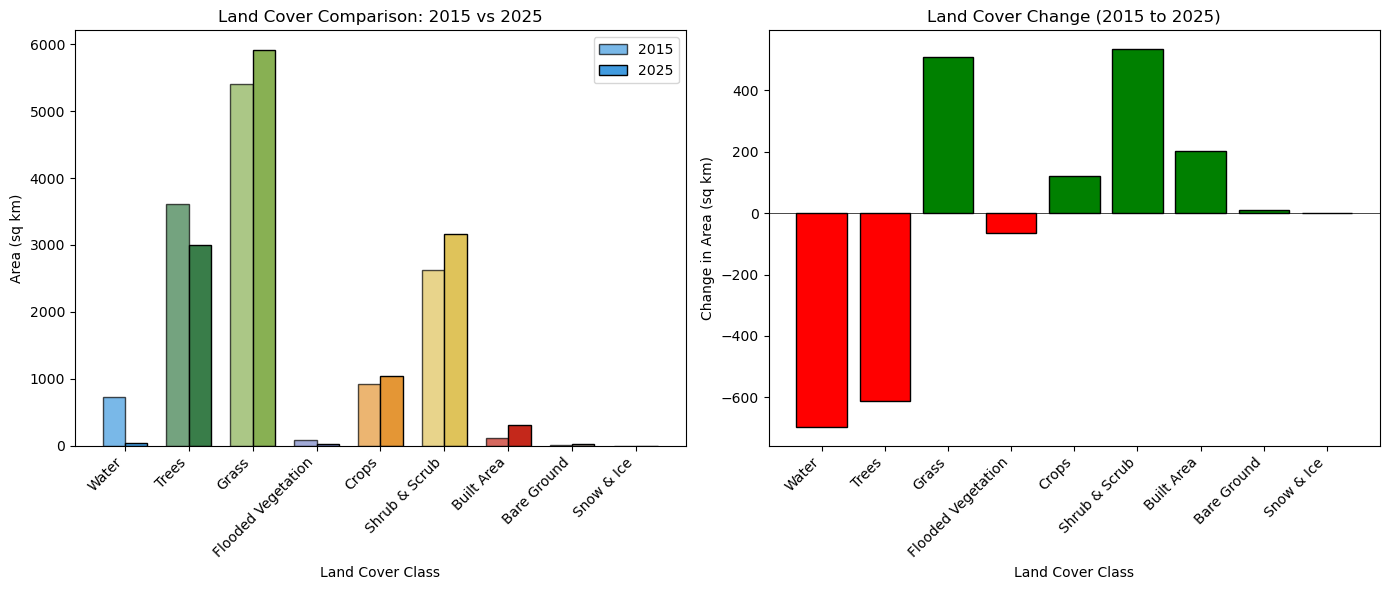

In [75]:
# Create comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart comparing both years
x = range(len(df_combined))
width = 0.35

colors = [DW_CLASSES[i]['color'] for i in df_combined['Class ID']]

axes[0].bar([i - width/2 for i in x], df_combined[f'Area {YEAR_1} (sq km)'], 
            width, label=str(YEAR_1), color=colors, alpha=0.7, edgecolor='black')
axes[0].bar([i + width/2 for i in x], df_combined[f'Area {YEAR_2} (sq km)'], 
            width, label=str(YEAR_2), color=colors, alpha=1.0, edgecolor='black')

axes[0].set_xlabel('Land Cover Class')
axes[0].set_ylabel('Area (sq km)')
axes[0].set_title(f'Land Cover Comparison: {YEAR_1} vs {YEAR_2}')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_combined['Class Name'], rotation=45, ha='right')
axes[0].legend()

# Change bar chart
change_colors = ['green' if c > 0 else 'red' for c in df_combined['Change (sq km)']]
axes[1].bar(x, df_combined['Change (sq km)'], color=change_colors, edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_xlabel('Land Cover Class')
axes[1].set_ylabel('Change in Area (sq km)')
axes[1].set_title(f'Land Cover Change ({YEAR_1} to {YEAR_2})')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_combined['Class Name'], rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 5.6 Change Detection Map

In [76]:
# Create a change detection image
change_mask = lc_year1.neq(lc_year2)

change_map = geemap.Map(layer_ctrl=False, data_ctrl=False, toolbar_ctrl=False)
change_map.centerObject(roi, zoom=10)

# Add base layer (year 2)
change_map.addLayer(lc_year2, dw_vis, f'Land Cover {YEAR_2}')

# Add change areas highlighted
change_map.addLayer(
    change_mask.selfMask(),
    {'palette': ['red']},
    'Areas of Change',
    opacity=0.7
)

# Add river
change_map.addLayer(
    river_ee.style(**{'color': RIVER_COLOR, 'width': 2}),
    {},
    'River'
)

# Add basin boundary
change_map.addLayer(
    basin_ee.style(**{'color': BASIN_COLOR, 'fillColor': '00000000', 'width': 2}),
    {},
    'Basin Boundary'
)

# Add legends
change_map.add_legend(title='Land Cover Classes', keys=legend_labels, colors=legend_colors)

reference_keys = ['Basin Boundary', 'River']
reference_colors = [BASIN_COLOR, RIVER_COLOR]
change_map.add_legend(keys=reference_keys, colors=reference_colors, position='topright')

change_map

Map(center=[-1.3843255052810637, 35.071029768653396], controls=(WidgetControl(options=['position', 'transparen…

## 5.7 Transition Matrix Heatmap

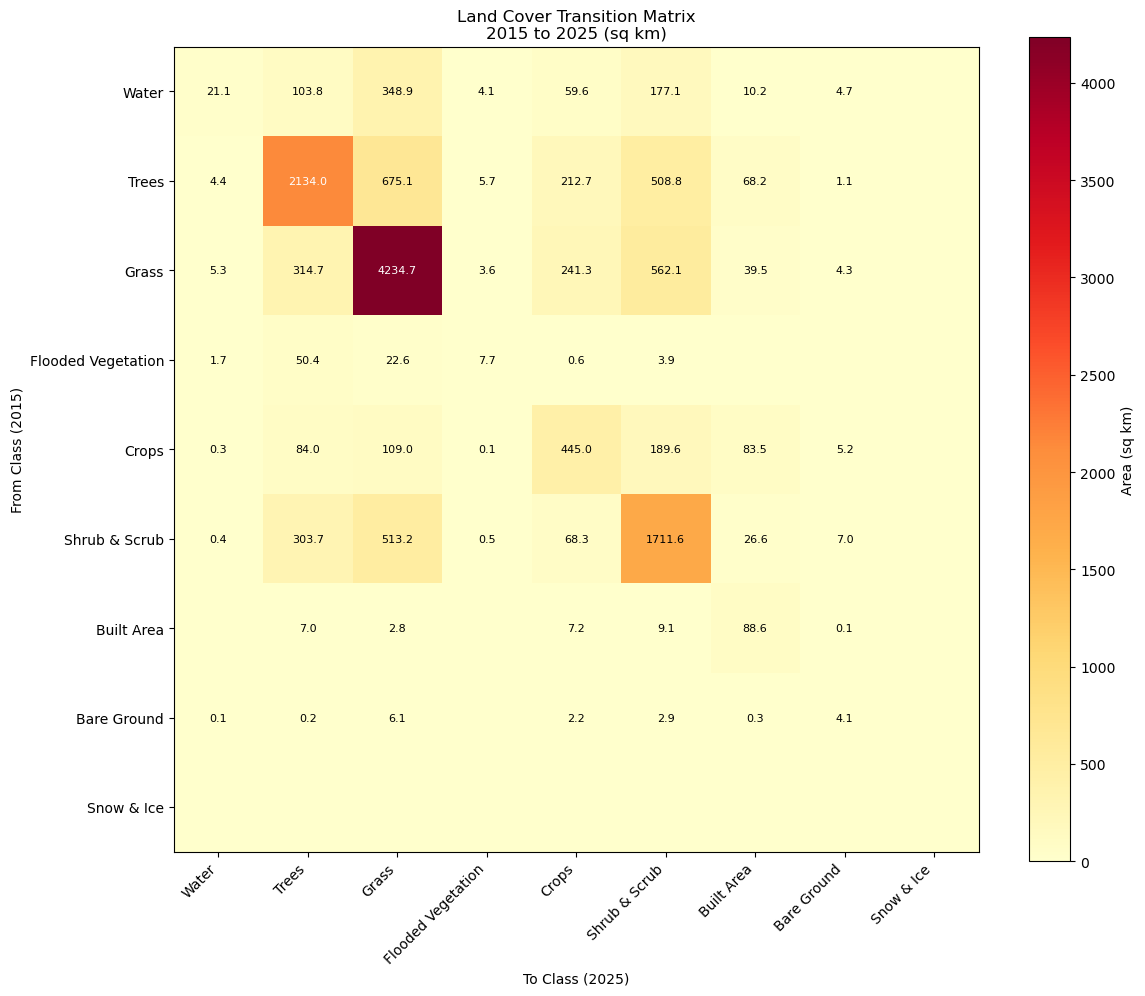

In [77]:
# Visualize transition matrix as heatmap
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(matrix.values, cmap='YlOrRd')

ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(matrix.index)

ax.set_xlabel(f'To Class ({YEAR_2})')
ax.set_ylabel(f'From Class ({YEAR_1})')
ax.set_title(f'Land Cover Transition Matrix\n{YEAR_1} to {YEAR_2} (sq km)')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Area (sq km)')

# Add text annotations for significant transitions
for i in range(n_classes):
    for j in range(n_classes):
        value = matrix.iloc[i, j]
        if value > 0.1:  # Only show if > 0.1 sq km
            text_color = 'white' if value > matrix.values.max() * 0.5 else 'black'
            ax.text(j, i, f'{value:.1f}', ha='center', va='center', 
                   color=text_color, fontsize=8)

plt.tight_layout()
plt.show()

## 5.8 Sankey Diagram

In [78]:
# Visualize transition matrix as Sankey diagram
import plotly.graph_objects as go

THRESHOLD = 1.0  # sq km - adjust to filter small transitions

class_names = [DW_CLASSES[i]['name'] for i in range(n_classes)]
class_colors = [DW_CLASSES[i]['color'] for i in range(n_classes)]

node_labels = [f"{name} ({YEAR_1})" for name in class_names] + [f"{name} ({YEAR_2})" for name in class_names]
node_colors = class_colors + class_colors

sources = []
targets = []
values = []
link_colors = []

for i, from_class in enumerate(class_names):
    for j, to_class in enumerate(class_names):
        value = matrix.iloc[i, j]
        if value > THRESHOLD:
            sources.append(i)
            targets.append(j + n_classes)
            values.append(value)
            hex_color = class_colors[i]
            r = int(hex_color[1:3], 16)
            g = int(hex_color[3:5], 16)
            b = int(hex_color[5:7], 16)
            link_colors.append(f'rgba({r},{g},{b},0.5)')

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color='black', width=0.5),
        label=node_labels,
        color=node_colors
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors
    )
)])

fig.update_layout(
    title=dict(
        text=f'Land Cover Transitions: {YEAR_1} to {YEAR_2}',
        font=dict(size=16)
    ),
    font=dict(size=12),
    height=600,
    width=1000
)

fig.show()

print(f'\nShowing transitions > {THRESHOLD} sq km')
print(f'Total transitions shown: {len(values)}')


Showing transitions > 1.0 sq km
Total transitions shown: 50


## 5.9 3D Population Visualization

In [71]:
# Create Three.js 3D visualization with all layers + Wetland overlays
def format_pop(val):
    if val >= 1000:
        return f"{val/1000:.1f}K"
    elif val >= 1:
        return f"{val:.0f}"
    else:
        return f"{val:.2f}"

scale_max = actual_pop_95
scale_75 = actual_pop_95 * 0.75
scale_50 = actual_pop_95 * 0.5
scale_25 = actual_pop_95 * 0.25

print(f"Population legend: 0 to {format_pop(scale_max)}+ (95th percentile)")
print(f"Altitude legend: {dem_min:.0f}m to {dem_max:.0f}m")
print(f"Slope legend: 0° to {slope_95:.0f}°+ (95th percentile)")
print(f"Rainfall legend: {rainfall_min:.0f} to {rainfall_max:.0f} mm/year")
print(f"Grid size: {rows} x {cols}")
print(f"River segments: {len(river_lines)}")
for wlc in wetland_layers_coords:
    print(f"  {wlc['label']}: {len(wlc['coords'])} polygons")
print(f"Land Cover layers: {YEAR_1} and {YEAR_2}")

aspect_ratio = cols / rows if rows > 0 else 1
basemap_texture = basemap_data_url if basemap_data_url else ""

threejs_html = f'''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="utf-8">
    <title>River Basin 3D Visualization</title>
    <style>
        body {{ margin: 0; overflow: hidden; }}
        canvas {{ display: block; }}
        #controls {{
            position: absolute; top: 10px; left: 10px; z-index: 100;
            background: rgba(0,0,0,0.85); padding: 15px; border-radius: 8px;
            color: white; font-family: -apple-system, sans-serif; font-size: 13px;
            min-width: 260px; max-height: 90vh; overflow-y: auto;
        }}
        #controls h3 {{ margin: 0 0 10px 0; font-size: 15px; }}
        #controls .subtitle {{ font-size: 11px; color: #aaa; margin-bottom: 12px; padding-bottom: 10px; border-bottom: 1px solid #444; }}
        #controls input[type="range"] {{ width: 100%; margin-top: 4px; }}
        .control-group {{ margin-bottom: 10px; }}
        .control-label {{ font-size: 11px; color: #aaa; margin-bottom: 2px; }}
        .countries {{ margin: 8px 0; }}
        .countries span {{ display: inline-block; padding: 2px 8px; margin: 2px; border-radius: 4px; font-size: 11px; }}
        .kenya {{ background: #4CAF50; }}
        .tanzania {{ background: #2196F3; }}
        #colorbar-container {{
            position: absolute; right: 20px; top: 50%; transform: translateY(-50%);
            background: rgba(0,0,0,0.85); padding: 15px; border-radius: 8px;
        }}
        #colorbar-title {{ color: white; font-family: sans-serif; font-size: 12px; text-align: center; margin-bottom: 8px; }}
        #colorbar {{ width: 25px; height: 180px; border: 1px solid white; }}
        #colorbar.population {{ background: linear-gradient(to bottom, #f2ebe0, #c4b59d, #8b7355, #5c4a3d, #2d2520); }}
        #colorbar.terrain {{ background: linear-gradient(to bottom, #f5f5f5, #8B4513, #228B22, #90EE90, #006400); }}
        #colorbar.slope {{ background: linear-gradient(to bottom, #67000d, #a50f15, #cb181d, #ef3b2c, #fb6a4a, #fc9272, #fcbba1, #fee5d9); }}
        #colorbar.rainfall {{ background: linear-gradient(to bottom, #08306b, #2171b5, #4292c6, #6baed6, #9ecae1, #c6dbef, #deebf7, #f7fbff); }}
        #colorbar-labels {{ color: white; font-family: sans-serif; font-size: 11px; display: flex; flex-direction: column; justify-content: space-between; height: 180px; margin-left: 8px; }}
        #colorbar-row {{ display: flex; align-items: stretch; }}
        #loading {{ position: absolute; top: 50%; left: 50%; transform: translate(-50%, -50%); color: white; font-family: sans-serif; font-size: 18px; background: rgba(0,0,0,0.8); padding: 20px 40px; border-radius: 10px; }}
        .info-text {{ font-size: 10px; color: #888; margin-top: 12px; border-top: 1px solid #444; padding-top: 10px; }}
        .layer-toggle {{ background: #333; padding: 8px; border-radius: 4px; margin-top: 8px; }}
        .layer-toggle label {{ display: block; margin: 4px 0; cursor: pointer; }}
        .layer-section {{ margin-top: 8px; padding-top: 8px; border-top: 1px solid #444; }}
        .overlay-item {{ display: flex; align-items: center; margin: 4px 0; }}
        .overlay-swatch {{ width: 16px; height: 16px; margin-right: 8px; border: 1px solid #666; border-radius: 2px; }}
    </style>
</head>
<body>
    <div id="loading">Loading terrain...</div>
    
    <div id="controls" style="display:none;">
        <h3>River Basin 3D</h3>
        <div class="subtitle">
            Trans-boundary River Basin
            <div class="countries">
                <span class="kenya">Kenya</span>
                <span class="tanzania">Tanzania</span>
            </div>
        </div>
        
        <div class="layer-toggle">
            <div class="control-label">Base Layer</div>
            <label><input type="radio" name="layer" value="dem" checked> Altitude</label>
            <label><input type="radio" name="layer" value="slope"> Slope</label>
            <label><input type="radio" name="layer" value="rainfall"> Rainfall</label>
            <label><input type="radio" name="layer" value="population"> Population</label>
            <label><input type="radio" name="layer" value="landcover1"> Land Cover {YEAR_1}</label>
            <label><input type="radio" name="layer" value="landcover2"> Land Cover {YEAR_2}</label>
        </div>
        
        <div class="layer-section">
<div class="control-label">Wetland Extent</div>
{"".join(f'<label style="margin: 0;"><input type="checkbox" checked id="showWetland{i}"> <span style="color: {wlc["color"]};">&#9632;</span> {wlc["label"]}</label>' for i, wlc in enumerate(wetland_layers_coords))}
        </div>
        
        <div class="layer-section">
            <div class="control-group">
                <div class="control-label">Elevation Scale: <span id="scaleVal">1.5</span>x</div>
                <input type="range" id="elevScale" min="0.5" max="5" step="0.1" value="1.5">
            </div>
            
            <div class="control-group">
                <label style="margin: 0;"><input type="checkbox" id="autoRotate"> Auto-rotate</label>
            </div>
            
            <div class="control-group">
                </div>
            
            <div class="control-group">
                <label style="margin: 0;"><input type="checkbox" id="showRiver" checked> Show River</label>
            </div>
        </div>
        
        <div class="info-text">
            Drag to rotate | Scroll to zoom<br>
            Shift+drag to pan<br><br>
            Extent: {min_lat:.3f} to {max_lat:.3f} N<br>
            {min_lon:.3f} to {max_lon:.3f} E
        </div>
    </div>
    
    <div id="colorbar-container" style="display:none;">
        <div id="colorbar-title">Population<br>Density</div>
        <div id="colorbar-row">
            <div id="colorbar" class="viridis"></div>
            <div id="colorbar-labels">
                <span id="label-max">{format_pop(scale_max)}+</span>
                <span id="label-75">{format_pop(scale_75)}</span>
                <span id="label-50">{format_pop(scale_50)}</span>
                <span id="label-25">{format_pop(scale_25)}</span>
                <span id="label-min">0</span>
            </div>
        </div>
    </div>
    
    <div id="landcover-legend" style="display:none; position: absolute; right: 20px; top: 50%; transform: translateY(-50%);
            background: rgba(0,0,0,0.85); padding: 15px; border-radius: 8px; color: white; font-family: sans-serif; font-size: 11px;">
        <div id="lc-legend-title" style="text-align: center; margin-bottom: 10px; font-weight: bold;">Land Cover</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #419BDF; margin-right: 8px; border-radius: 2px;"></div>Water</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #397D49; margin-right: 8px; border-radius: 2px;"></div>Trees</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #88B053; margin-right: 8px; border-radius: 2px;"></div>Grass</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #7A87C6; margin-right: 8px; border-radius: 2px;"></div>Flooded Veg</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #E49635; margin-right: 8px; border-radius: 2px;"></div>Crops</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #DFC35A; margin-right: 8px; border-radius: 2px;"></div>Shrub/Scrub</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #C4281B; margin-right: 8px; border-radius: 2px;"></div>Built Area</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #A59B8F; margin-right: 8px; border-radius: 2px;"></div>Bare Ground</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #B39FE1; margin-right: 8px; border-radius: 2px;"></div>Snow/Ice</div>
    </div>

    <script src="https://cdnjs.cloudflare.com/ajax/libs/three.js/r128/three.min.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/three@0.128.0/examples/js/controls/OrbitControls.js"></script>
    <script>
        const popHeightB64 = "{height_data_b64}";
        const demHeightB64 = "{dem_height_data_b64}";
        const slopeHeightB64 = "{slope_height_data_b64}";
        const rainfallHeightB64 = "{rainfall_height_data_b64}";
        const rows = {rows};
        const cols = {cols};
        const aspectRatio = {aspect_ratio};
        const basinOutline = {json.dumps(basin_outline)};
        const riverLines = {json.dumps(river_lines)};
        const wetlandLayers = {json.dumps(wetland_layers_coords)};
        const lcYear1B64 = "{lc_data_year1_b64}";
        const lcYear2B64 = "{lc_data_year2_b64}";

        // Decode base64 to flat typed arrays (no 2D conversion for speed)
        console.log('Decoding data...');
        console.log('popHeightB64 length:', popHeightB64.length);
        console.log('rows:', rows, 'cols:', cols);
        function b64ToBytes(b64) {{
            try {{
                console.log('  b64ToBytes: input length', b64.length);
                const bin = atob(b64);
                console.log('  atob done, binary length:', bin.length);
                const bytes = new Uint8Array(bin.length);
                for (let i = 0; i < bin.length; i++) bytes[i] = bin.charCodeAt(i);
                console.log('  bytes created');
                return bytes;
            }} catch(e) {{
                console.error('b64ToBytes error:', e);
                document.getElementById('loading').textContent = 'Decode error: ' + e.message;
                throw e;
            }}
        }}
        // Flat typed arrays - access as flat[row * cols + col]
        console.log('Decoding popFlat...');
        const popFlat = popHeightB64 ? new Float32Array(b64ToBytes(popHeightB64).buffer) : null;
        const demFlat = demHeightB64 ? new Float32Array(b64ToBytes(demHeightB64).buffer) : null;
        const slopeFlat = slopeHeightB64 ? new Float32Array(b64ToBytes(slopeHeightB64).buffer) : null;
        const rainfallFlat = rainfallHeightB64 ? new Float32Array(b64ToBytes(rainfallHeightB64).buffer) : null;
        const lcYear1Flat = lcYear1B64 ? b64ToBytes(lcYear1B64) : null;
        console.log('Decoding lcYear2Flat...');
        const lcYear2Flat = lcYear2B64 ? b64ToBytes(lcYear2B64) : null;
        console.log('All data decoded. popFlat:', popFlat?.length, 'demFlat:', demFlat?.length, 'lcYear1Flat:', lcYear1Flat?.length);
        
        // Dynamic World class colors (RGB normalized to 0-1)
        const dwColors = {{
            0: [0.255, 0.608, 0.875],  // Water - #419BDF
            1: [0.224, 0.490, 0.286],  // Trees - #397D49
            2: [0.533, 0.690, 0.325],  // Grass - #88B053
            3: [0.478, 0.529, 0.776],  // Flooded Vegetation - #7A87C6
            4: [0.894, 0.588, 0.208],  // Crops - #E49635
            5: [0.875, 0.765, 0.353],  // Shrub & Scrub - #DFC35A
            6: [0.769, 0.157, 0.106],  // Built Area - #C4281B
            7: [0.647, 0.608, 0.561],  // Bare Ground - #A59B8F
            8: [0.702, 0.624, 0.882],  // Snow & Ice - #B39FE1
            255: [0.2, 0.2, 0.2]       // No data - dark gray
        }};
        const dwClassNames = ['Water', 'Trees', 'Grass', 'Flooded Veg', 'Crops', 'Shrub/Scrub', 'Built Area', 'Bare Ground', 'Snow/Ice'];
        const basemapDataUrl = "{basemap_texture}";
        const demMin = {dem_min};
        const demMax = {dem_max};
        const slopeMax = {slope_95};
        const popMax = {scale_max};
        const rainfallMin = {rainfall_min};
        const rainfallMax = {rainfall_max};

        console.log('Creating THREE.js scene...');
        const scene = new THREE.Scene();
        scene.background = new THREE.Color(0x1a1a2e);

        const camera = new THREE.PerspectiveCamera(60, window.innerWidth / window.innerHeight, 0.1, 1000);
        const renderer = new THREE.WebGLRenderer({{ antialias: true }});
        renderer.setSize(window.innerWidth, window.innerHeight);
        document.body.appendChild(renderer.domElement);

        const controls = new THREE.OrbitControls(camera, renderer.domElement);
        controls.enableDamping = true;
        controls.dampingFactor = 0.05;
        controls.autoRotate = false;
        controls.autoRotateSpeed = 0.3;

        scene.add(new THREE.AmbientLight(0xffffff, 0.6));
        const dirLight = new THREE.DirectionalLight(0xffffff, 0.8);
        dirLight.position.set(5, 10, 5);
        scene.add(dirLight);

        let elevationScale = 1.5;
        let terrainMesh = null;
        let boundaryLine = null;
        let riverLineObjects = [];
        let wetlandMeshes = wetlandLayers.map(() => []);
        let satelliteTexture = null;
        let currentLayer = 'dem';
        let showRiver = true;
        
        function landcoverColor(classValue, year) {{
            const dataFlat = year === 1 ? lcYear1Flat : lcYear2Flat;
            const color = dwColors[classValue] || dwColors[255];
            return color;
        }}
        let showWetland = wetlandLayers.map(() => true);
        let planeWidth, planeHeight;

        // Color functions
        function viridis(t) {{
            t = Math.max(0, Math.min(1, t));
            const colors = [[0.267,0.004,0.329],[0.282,0.140,0.458],[0.231,0.322,0.545],[0.129,0.569,0.549],[0.369,0.788,0.384],[0.993,0.906,0.144]];
            const positions = [0, 0.15, 0.3, 0.5, 0.7, 1.0];
            let lower = 0, upper = colors.length - 1;
            for (let i = 0; i < positions.length - 1; i++) {{ if (t >= positions[i] && t <= positions[i + 1]) {{ lower = i; upper = i + 1; break; }} }}
            const range = positions[upper] - positions[lower];
            const localT = range > 0 ? (t - positions[lower]) / range : 0;
            return [colors[lower][0] + localT * (colors[upper][0] - colors[lower][0]), colors[lower][1] + localT * (colors[upper][1] - colors[lower][1]), colors[lower][2] + localT * (colors[upper][2] - colors[lower][2])];
        }}

        function mutedPop(t) {{
            // Muted cream to brown palette for population
            t = Math.max(0, Math.min(1, t));
            const r = 0.95 - t * 0.45;
            const g = 0.92 - t * 0.52;
            const b = 0.85 - t * 0.55;
            return [Math.max(0.1, r), Math.max(0.1, g), Math.max(0.1, b)];
        }}
        
        function terrain(t) {{
            t = Math.max(0, Math.min(1, t));
            const colors = [[0.0,0.39,0.0],[0.56,0.93,0.56],[0.55,0.27,0.07],[0.72,0.53,0.04],[0.96,0.96,0.96]];
            const positions = [0, 0.25, 0.5, 0.75, 1.0];
            let lower = 0, upper = colors.length - 1;
            for (let i = 0; i < positions.length - 1; i++) {{ if (t >= positions[i] && t <= positions[i + 1]) {{ lower = i; upper = i + 1; break; }} }}
            const range = positions[upper] - positions[lower];
            const localT = range > 0 ? (t - positions[lower]) / range : 0;
            return [colors[lower][0] + localT * (colors[upper][0] - colors[lower][0]), colors[lower][1] + localT * (colors[upper][1] - colors[lower][1]), colors[lower][2] + localT * (colors[upper][2] - colors[lower][2])];
        }}

        function slopeColor(t) {{
            t = Math.max(0, Math.min(1, t));
            const colors = [[0.996,0.898,0.851],[0.988,0.733,0.631],[0.984,0.416,0.290],[0.796,0.094,0.114],[0.404,0.0,0.051]];
            const positions = [0, 0.25, 0.5, 0.75, 1.0];
            let lower = 0, upper = colors.length - 1;
            for (let i = 0; i < positions.length - 1; i++) {{ if (t >= positions[i] && t <= positions[i + 1]) {{ lower = i; upper = i + 1; break; }} }}
            const range = positions[upper] - positions[lower];
            const localT = range > 0 ? (t - positions[lower]) / range : 0;
            return [colors[lower][0] + localT * (colors[upper][0] - colors[lower][0]), colors[lower][1] + localT * (colors[upper][1] - colors[lower][1]), colors[lower][2] + localT * (colors[upper][2] - colors[lower][2])];
        }}

        function rainfallColor(t) {{
            t = Math.max(0, Math.min(1, t));
            const colors = [[0.969,0.984,1.0],[0.776,0.858,0.937],[0.420,0.682,0.839],[0.129,0.443,0.710],[0.031,0.188,0.420]];
            const positions = [0, 0.25, 0.5, 0.75, 1.0];
            let lower = 0, upper = colors.length - 1;
            for (let i = 0; i < positions.length - 1; i++) {{ if (t >= positions[i] && t <= positions[i + 1]) {{ lower = i; upper = i + 1; break; }} }}
            const range = positions[upper] - positions[lower];
            const localT = range > 0 ? (t - positions[lower]) / range : 0;
            return [colors[lower][0] + localT * (colors[upper][0] - colors[lower][0]), colors[lower][1] + localT * (colors[upper][1] - colors[lower][1]), colors[lower][2] + localT * (colors[upper][2] - colors[lower][2])];
        }}

        function getHeightAt(gx, gz, heightFlat) {{
            const x0 = Math.floor(gx), z0 = Math.floor(gz);
            const x1 = Math.min(x0 + 1, cols - 1), z1 = Math.min(z0 + 1, rows - 1);
            const fx = gx - x0, fz = gz - z0;
            const h00 = (heightFlat ? heightFlat[(Math.max(0, Math.min(z0, rows-1))) * cols + (Math.max(0, Math.min(x0, cols-1)))] : 0);
            const h10 = (heightFlat ? heightFlat[(Math.max(0, Math.min(z0, rows-1))) * cols + (Math.max(0, Math.min(x1, cols-1)))] : 0);
            const h01 = (heightFlat ? heightFlat[(Math.max(0, Math.min(z1, rows-1))) * cols + (Math.max(0, Math.min(x0, cols-1)))] : 0);
            const h11 = (heightFlat ? heightFlat[(Math.max(0, Math.min(z1, rows-1))) * cols + (Math.max(0, Math.min(x1, cols-1)))] : 0);
            return (h00 * (1-fx) + h10 * fx) * (1-fz) + (h01 * (1-fx) + h11 * fx) * fz;
        }}

        function createRiverLines() {{
            riverLineObjects.forEach(l => {{ scene.remove(l); l.geometry.dispose(); l.material.dispose(); }});
            riverLineObjects = [];
            if (!showRiver) return;
            
            const useDemHeight = (currentLayer === 'dem' || currentLayer === 'slope' || currentLayer === 'rainfall' || currentLayer === 'landcover1' || currentLayer === 'landcover2');
            const heightFlat = useDemHeight ? demFlat : popFlat;
            const riverMaterial = new THREE.LineBasicMaterial({{ color: 0x0000CD, linewidth: 2 }});
            
            for (const lineCoords of riverLines) {{
                if (lineCoords.length < 2) continue;
                const points = lineCoords.map(c => {{
                    const x = (c[0] / cols - 0.5) * planeWidth;
                    const z = (c[1] / rows - 0.5) * planeHeight;
                    const y = getHeightAt(c[0], c[1], heightFlat) * elevationScale + 0.03;
                    return new THREE.Vector3(x, y, z);
                }});
                const lineGeom = new THREE.BufferGeometry().setFromPoints(points);
                const riverLine = new THREE.Line(lineGeom, riverMaterial);
                scene.add(riverLine);
                riverLineObjects.push(riverLine);
            }}
        }}

        function createWetlandOverlay(polygons, meshArray, color, opacity, renderOrderVal) {{
            meshArray.forEach(m => {{ scene.remove(m); m.geometry.dispose(); m.material.dispose(); }});
            meshArray.length = 0;
            
            const useDemHeight = (currentLayer === 'dem' || currentLayer === 'slope' || currentLayer === 'rainfall' || currentLayer === 'landcover1' || currentLayer === 'landcover2');
            const heightFlat = useDemHeight ? demFlat : popFlat;
            
            const material = new THREE.MeshBasicMaterial({{
                color: color,
                opacity: opacity,
                transparent: true,
                side: THREE.DoubleSide,
                depthWrite: false,
                depthTest: false  // Always render on top of terrain
            }});
            
            for (const polygon of polygons) {{
                if (polygon.length < 3) continue;
                
                // Create shape from polygon coordinates
                const shape = new THREE.Shape();
                const firstPt = polygon[0];
                const x0 = (firstPt[0] / cols - 0.5) * planeWidth;
                const z0 = (firstPt[1] / rows - 0.5) * planeHeight;
                shape.moveTo(x0, -z0);
                
                for (let i = 1; i < polygon.length; i++) {{
                    const pt = polygon[i];
                    const x = (pt[0] / cols - 0.5) * planeWidth;
                    const z = (pt[1] / rows - 0.5) * planeHeight;
                    shape.lineTo(x, -z);
                }}
                shape.closePath();
                
                const shapeGeom = new THREE.ShapeGeometry(shape);
                shapeGeom.rotateX(-Math.PI / 2);
                
                // Calculate average terrain height for the polygon
                let avgHeight = 0;
                for (const pt of polygon) {{
                    avgHeight += getHeightAt(pt[0], pt[1], heightFlat);
                }}
                avgHeight = (avgHeight / polygon.length) * elevationScale;
                
                const mesh = new THREE.Mesh(shapeGeom, material.clone());
                // Position just slightly above terrain surface
                mesh.position.y = avgHeight + 0.02;
                mesh.renderOrder = renderOrderVal;
                scene.add(mesh);
                meshArray.push(mesh);
            }}
        }}

        function updateWetlandOverlays() {{
            wetlandMeshes.forEach((arr) => {{
                arr.forEach(m => {{ scene.remove(m); m.geometry.dispose(); m.material.dispose(); }});
                arr.length = 0;
            }});

            wetlandLayers.forEach((wl, i) => {{
                if (showWetland[i]) {{
                    const c = parseInt(wl.color.replace('#',''), 16);
                    createWetlandOverlay(wl.coords, wetlandMeshes[i], c, 0.75, 100 + i);
                }}
            }});
        }}

        function createTerrain() {{
            if (terrainMesh) {{ scene.remove(terrainMesh); terrainMesh.geometry.dispose(); terrainMesh.material.dispose(); }}
            if (boundaryLine) {{ scene.remove(boundaryLine); boundaryLine.geometry.dispose(); }}

            planeWidth = 10 * aspectRatio;
            planeHeight = 10;
            
            const geometry = new THREE.PlaneGeometry(planeWidth, planeHeight, cols - 1, rows - 1);
            geometry.rotateX(-Math.PI / 2);
            
            const positions = geometry.attributes.position.array;
            const colors = new Float32Array(positions.length);
            
            const usePopHeight = (currentLayer === 'population' || currentLayer === 'satellite');
            const useDemHeight = (currentLayer === 'dem' || currentLayer === 'slope' || currentLayer === 'rainfall' || currentLayer === 'landcover1' || currentLayer === 'landcover2');
            
            for (let i = 0; i < rows; i++) {{
                for (let j = 0; j < cols; j++) {{
                    const vertIdx = (i * cols + j) * 3;
                    const popValue = (popFlat ? popFlat[i * cols + j] : 0);
                    const demValue = (demFlat ? demFlat[i * cols + j] : 0);
                    const slopeValue = (slopeFlat ? slopeFlat[i * cols + j] : 0);
                    const rainfallValue = (rainfallFlat ? rainfallFlat[i * cols + j] : 0);
                    const lcValue1 = (lcYear1Flat ? lcYear1Flat[i * cols + j] : 255);
                    const lcValue2 = (lcYear2Flat ? lcYear2Flat[i * cols + j] : 255);
                    
                    positions[vertIdx + 1] = (useDemHeight ? demValue : popValue) * elevationScale;
                    
                    let rgb;
                    if (currentLayer === 'population' || false) rgb = mutedPop(popValue);
                    else if (currentLayer === 'slope') rgb = slopeColor(slopeValue);
                    else if (currentLayer === 'rainfall') rgb = rainfallColor(rainfallValue);
                    else if (currentLayer === 'landcover1') rgb = dwColors[lcValue1] || dwColors[255];
                    else if (currentLayer === 'landcover2') rgb = dwColors[lcValue2] || dwColors[255];
                    else rgb = terrain(demValue);
                    
                    colors[vertIdx] = rgb[0];
                    colors[vertIdx + 1] = rgb[1];
                    colors[vertIdx + 2] = rgb[2];
                }}
            }}
            
            geometry.setAttribute('color', new THREE.BufferAttribute(colors, 3));
            geometry.attributes.position.needsUpdate = true;
            geometry.computeVertexNormals();

            const material = new THREE.MeshLambertMaterial({{ vertexColors: true, side: THREE.DoubleSide }});
            terrainMesh = new THREE.Mesh(geometry, material);
            scene.add(terrainMesh);

            if (currentLayer === 'satellite' && satelliteTexture) {{
                terrainMesh.material.map = satelliteTexture;
                terrainMesh.material.vertexColors = false;
                terrainMesh.material.needsUpdate = true;
            }}

            // Basin boundary
            const boundaryPoints = basinOutline.map(c => {{
                const x = (c[0] / cols - 0.5) * planeWidth;
                const z = (c[1] / rows - 0.5) * planeHeight;
                const h = useDemHeight ? ((demFlat ? demFlat[Math.floor(c[1]) * cols + Math.floor(c[0])] : 0)) : ((popFlat ? popFlat[Math.floor(c[1]) * cols + Math.floor(c[0])] : 0));
                return new THREE.Vector3(x, h * elevationScale + 0.02, z);
            }});
            if (boundaryPoints.length > 0) boundaryPoints.push(boundaryPoints[0].clone());
            
            const lineGeom = new THREE.BufferGeometry().setFromPoints(boundaryPoints);
            boundaryLine = new THREE.Line(lineGeom, new THREE.LineBasicMaterial({{ color: 0xff4444 }}));
            scene.add(boundaryLine);

            createRiverLines();
            updateWetlandOverlays();

            camera.position.set(planeWidth * 0.3, planeHeight * 1.2, planeHeight * 0.9);
            controls.target.set(0, 0, 0);
            controls.update();
        }}

        function updateColorbar() {{
            const colorbar = document.getElementById('colorbar');
            const title = document.getElementById('colorbar-title');
            const labels = ['label-max', 'label-75', 'label-50', 'label-25', 'label-min'].map(id => document.getElementById(id));
            
            if (currentLayer === 'dem') {{
                colorbar.className = 'terrain';
                title.innerHTML = 'Altitude<br>(meters)';
                [demMax, demMin + (demMax-demMin)*0.75, demMin + (demMax-demMin)*0.5, demMin + (demMax-demMin)*0.25, demMin].forEach((v,i) => labels[i].textContent = Math.round(v) + 'm');
            }} else if (currentLayer === 'slope') {{
                colorbar.className = 'slope';
                title.innerHTML = 'Slope<br>(degrees)';
                [slopeMax, slopeMax*0.75, slopeMax*0.5, slopeMax*0.25, 0].forEach((v,i) => labels[i].textContent = Math.round(v) + '°' + (i===0?'+':''));
            }} else if (currentLayer === 'rainfall') {{
                colorbar.className = 'rainfall';
                title.innerHTML = 'Rainfall<br>(mm/year)';
                [rainfallMax, rainfallMin+(rainfallMax-rainfallMin)*0.75, rainfallMin+(rainfallMax-rainfallMin)*0.5, rainfallMin+(rainfallMax-rainfallMin)*0.25, rainfallMin].forEach((v,i) => labels[i].textContent = Math.round(v) + 'mm');
            }} else if (currentLayer === 'landcover1' || currentLayer === 'landcover2') {{
                // Show discrete legend for land cover instead of gradient colorbar
                document.getElementById('colorbar-container').style.display = 'none';
                const lcLegend = document.getElementById('landcover-legend');
                if (lcLegend) {{
                    lcLegend.style.display = 'block';
                    document.getElementById('lc-legend-title').textContent = currentLayer === 'landcover1' ? 'Land Cover {YEAR_1}' : 'Land Cover {YEAR_2}';
                }}
                return;
            }} else if (currentLayer === 'satellite') {{
                document.getElementById('colorbar-container').style.display = 'none';
                return;
            }} else {{
                colorbar.className = 'population';
                title.innerHTML = 'Population<br>Density';
                labels[0].textContent = '{format_pop(scale_max)}+';
                labels[1].textContent = '{format_pop(scale_75)}';
                labels[2].textContent = '{format_pop(scale_50)}';
                labels[3].textContent = '{format_pop(scale_25)}';
                labels[4].textContent = '0';
            }}
            document.getElementById('colorbar-container').style.display = 'block';
                const lcLegendHide = document.getElementById('landcover-legend');
                if (lcLegendHide) lcLegendHide.style.display = 'none';
        }}

        // Load satellite texture
        if (basemapDataUrl && basemapDataUrl.length > 50) {{
            new THREE.TextureLoader().load(basemapDataUrl, tex => {{ satelliteTexture = tex; }});
        }}

        try {{
            console.log('Starting terrain creation...');
            createTerrain();
            console.log('Terrain created, updating colorbar...');
            updateColorbar();
            console.log('All done, hiding loading screen');
            document.getElementById('loading').style.display = 'none';
        }} catch(e) {{
            console.error('INIT ERROR:', e);
            document.getElementById('loading').textContent = 'Error: ' + e.message;
        }}
        document.getElementById('controls').style.display = 'block';
        document.getElementById('colorbar-container').style.display = 'block';
                const lcLegendHide = document.getElementById('landcover-legend');
                if (lcLegendHide) lcLegendHide.style.display = 'none';

        // Event listeners
        document.querySelectorAll('input[name="layer"]').forEach(r => r.addEventListener('change', e => {{
            currentLayer = e.target.value;
            createTerrain();
            updateColorbar();
        }}));

        document.getElementById('elevScale').addEventListener('input', e => {{
            elevationScale = parseFloat(e.target.value);
            document.getElementById('scaleVal').textContent = elevationScale.toFixed(1);
            createTerrain();
        }});

        

        document.getElementById('autoRotate').addEventListener('change', e => {{
            controls.autoRotate = e.target.checked;
        }});

        document.getElementById('showRiver').addEventListener('change', e => {{
            showRiver = e.target.checked;
            createRiverLines();
        }});

        wetlandLayers.forEach((wl, i) => {{
            const el = document.getElementById('showWetland' + i);
            if (el) el.addEventListener('change', e => {{
                showWetland[i] = e.target.checked;
                updateWetlandOverlays();
            }});
        }});

        function animate() {{
            requestAnimationFrame(animate);
            controls.update();
            renderer.render(scene, camera);
        }}
        animate();

        window.addEventListener('resize', () => {{
            camera.aspect = window.innerWidth / window.innerHeight;
            camera.updateProjectionMatrix();
            renderer.setSize(window.innerWidth, window.innerHeight);
        }});
    </script>
</body>
</html>
'''

html_file = os.path.join(OUTPUT_DIR, 'population_3d_visualization.html')
with open(html_file, 'w') as f:
    f.write(threejs_html)

print(f"\n3D visualization saved to: {html_file}")
print(f"Available layers: Population, DEM, Slope, Rainfall, Satellite, Land Cover {YEAR_1}, Land Cover {YEAR_2}")
for wlc in wetland_layers_coords:
    print(f"  {wlc['label']}: {wlc['color']} - 75% opacity")

from IPython.display import IFrame
IFrame(html_file, width='100%', height='600px')

Population legend: 0 to 8+ (95th percentile)
Altitude legend: 1133m to 1562m
Slope legend: 0° to 5°+ (95th percentile)
Rainfall legend: 1166 to 2079 mm/year
Grid size: 627 x 938
River segments: 26
  Wetland: 0 polygons
Land Cover layers: 2015 and 2025

3D visualization saved to: Sio/output/population_3d_visualization.html
Available layers: Population, DEM, Slope, Rainfall, Satellite, Land Cover 2015, Land Cover 2025
  Wetland: #008080 - 75% opacity


---
# SECTION 6: EXPORTS
Export visualizations to HTML files and statistics to CSV.

## 6.1 Export Split Map to HTML

In [ ]:
# Export split map to standalone HTML using folium
# Uses base64-encoded PNG images (works in Streamlit iframes)
import os
import io
import base64
import folium
from folium.elements import Element
from pathlib import Path
from PIL import Image
import numpy as np

# Create output directory if it doesn't exist
output_path = get_cache_dir()
os.makedirs(output_path, exist_ok=True)

# --- Generate colored land cover PNGs from raster data ---
def raster_to_colored_png(lc_data, dw_colors, nodata_val=255):
    """Convert land cover class raster to RGBA PNG using DW color map."""
    h, w = lc_data.shape
    rgba = np.zeros((h, w, 4), dtype=np.uint8)
    for class_id, rgb in dw_colors.items():
        mask = lc_data == class_id
        rgba[mask, 0] = rgb[0]
        rgba[mask, 1] = rgb[1]
        rgba[mask, 2] = rgb[2]
        rgba[mask, 3] = 255  # fully opaque
    # nodata / outside basin -> transparent
    rgba[lc_data == nodata_val, 3] = 0
    return Image.fromarray(rgba, 'RGBA')

assert lc_data_year1 is not None and lc_data_year2 is not None, \
    "Land cover raster data not loaded. Run the land cover loading cell first."

print("Generating colored land cover PNGs...")
img_year1 = raster_to_colored_png(lc_data_year1, DW_COLORS)
img_year2 = raster_to_colored_png(lc_data_year2, DW_COLORS)

# Save PNGs to disk
png_path1 = os.path.join(output_path, f"landcover_{YEAR_1}.png")
png_path2 = os.path.join(output_path, f"landcover_{YEAR_2}.png")
img_year1.save(png_path1)
img_year2.save(png_path2)
print(f"  Saved: {png_path1} ({img_year1.size[0]}x{img_year1.size[1]})")
print(f"  Saved: {png_path2} ({img_year2.size[0]}x{img_year2.size[1]})")

# Encode as base64 data URIs
def png_to_data_uri(img):
    buf = io.BytesIO()
    img.save(buf, format='PNG')
    b64 = base64.b64encode(buf.getvalue()).decode('ascii')
    return f"data:image/png;base64,{b64}"

lc_uri_year1 = png_to_data_uri(img_year1)
lc_uri_year2 = png_to_data_uri(img_year2)
print(f"  Base64 sizes: {len(lc_uri_year1)//1024} KB, {len(lc_uri_year2)//1024} KB")

# --- Basemap URL (remote Google Satellite Hybrid - doesn't expire) ---
basemap_url = "https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}"

# Get basin bounds from Earth Engine
bounds_info = roi.bounds().getInfo()['coordinates'][0]
min_lon = min(p[0] for p in bounds_info)
max_lon = max(p[0] for p in bounds_info)
min_lat = min(p[1] for p in bounds_info)
max_lat = max(p[1] for p in bounds_info)

center_lat = (min_lat + max_lat) / 2
center_lon = (min_lon + max_lon) / 2

print(f"Basin bounds: [{min_lat:.4f}, {min_lon:.4f}] to [{max_lat:.4f}, {max_lon:.4f}]")
print(f"Center: [{center_lat:.4f}, {center_lon:.4f}]")

# Create folium map with zoom/pan disabled (static PNG, single zoom level)
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=ZOOM,
    tiles=None,
    zoom_control=False,
    dragging=False,
    scrollWheelZoom=False,
    doubleClickZoom=False,
    touchZoom=False,
    boxZoom=False
)
m.fit_bounds([[min_lat, min_lon], [max_lat, max_lon]])

# Add base layer (Google Satellite Hybrid)
folium.TileLayer(
    tiles=basemap_url,
    attr='Google Satellite Hybrid',
    name='Satellite Hybrid'
).add_to(m)

# Image bounds for overlays (SW corner, NE corner)
img_bounds = [[min_lat, min_lon], [max_lat, max_lon]]

# Add left layer (Year 1) - base64 PNG overlay
left_overlay = folium.raster_layers.ImageOverlay(
    image=lc_uri_year1,
    bounds=img_bounds,
    name=f'Land Cover {YEAR_1}',
    opacity=1.0,
    interactive=False
)
left_overlay.add_to(m)

# Add right layer (Year 2) - base64 PNG overlay
right_overlay = folium.raster_layers.ImageOverlay(
    image=lc_uri_year2,
    bounds=img_bounds,
    name=f'Land Cover {YEAR_2}',
    opacity=1.0,
    interactive=False
)
right_overlay.add_to(m)

# Add basin boundary
basin_geojson = basin_ee.getInfo()
folium.GeoJson(
    basin_geojson,
    name='Basin Boundary',
    style_function=lambda x: {
        'color': BASIN_COLOR,
        'weight': 2,
        'fillOpacity': 0
    }
).add_to(m)

# Add river
river_geojson = river_ee.getInfo()
folium.GeoJson(
    river_geojson,
    name='River',
    style_function=lambda x: {
        'color': RIVER_COLOR,
        'weight': 2
    }
).add_to(m)

# Add additional features to map
for feature in loaded_features:
    feat_type = feature.get('type', 'point')
    color = feature['color']
    name = feature['name']
    fill_opacity = feature.get('fill_opacity', 0.3)
    geojson_data = feature['gdf'].__geo_interface__
    
    if feat_type == 'point':
        size = feature.get('size', 8)
        for idx, row in feature['gdf'].iterrows():
            if row.geometry.geom_type == 'Point':
                folium.CircleMarker(
                    location=[row.geometry.y, row.geometry.x],
                    radius=size, color=color, fill=True,
                    fill_color=color, fill_opacity=0.8, popup=name
                ).add_to(m)
            elif row.geometry.geom_type == 'MultiPoint':
                for point in row.geometry.geoms:
                    folium.CircleMarker(
                        location=[point.y, point.x],
                        radius=size, color=color, fill=True,
                        fill_color=color, fill_opacity=0.8, popup=name
                    ).add_to(m)
    else:
        style_func = lambda x, c=color, ft=feat_type, fo=fill_opacity: {
            'color': c, 'weight': 2,
            'fillOpacity': fo if ft == 'polygon' else 0
        }
        folium.GeoJson(geojson_data, name=name, style_function=style_func).add_to(m)
    print(f"Added {name} to HTML map")

# --- Custom side-by-side clip slider (works with ImageOverlay) ---
# SideBySideLayers only works with TileLayer, so we implement our own
# using CSS clip-path on the ImageOverlay <img> elements.
split_slider_js = '''
<style>
#split-slider {
    position: absolute;
    top: 0; bottom: 0;
    width: 4px;
    background: white;
    left: 50%;
    z-index: 999;
    cursor: ew-resize;
    box-shadow: 0 0 6px rgba(0,0,0,0.5);
}
#split-handle {
    position: absolute;
    top: 50%;
    left: 50%;
    transform: translate(-50%, -50%);
    width: 36px; height: 36px;
    background: white;
    border-radius: 50%;
    box-shadow: 0 2px 6px rgba(0,0,0,0.4);
    display: flex; align-items: center; justify-content: center;
    font-size: 18px; color: #555;
    user-select: none;
    pointer-events: none;
}
</style>

<script>
document.addEventListener('DOMContentLoaded', function() {
    // Wait for map to render
    setTimeout(function() {
        var mapContainer = document.querySelector('.folium-map');
        if (!mapContainer) return;

        // Create slider divider
        var slider = document.createElement('div');
        slider.id = 'split-slider';
        var handle = document.createElement('div');
        handle.id = 'split-handle';
        handle.innerHTML = '&#x2194;';
        slider.appendChild(handle);
        mapContainer.style.position = 'relative';
        mapContainer.appendChild(slider);

        // Find the two ImageOverlay <img> elements
        function getImages() {
            return mapContainer.querySelectorAll('.leaflet-image-layer');
        }

        function updateClip(xPct) {
            slider.style.left = xPct + '%';
            var containerRect = mapContainer.getBoundingClientRect();
            var splitX = containerRect.left + (xPct / 100) * containerRect.width;
            var images = getImages();
            var leftImg = images.length >= 2 ? images[0] : null;
            var rightImg = images.length >= 2 ? images[1] : null;
            if (leftImg) {
                var r = leftImg.getBoundingClientRect();
                var clipRight = Math.max(0, Math.min(100, ((r.right - splitX) / r.width) * 100));
                leftImg.style.clipPath = 'inset(0 ' + clipRight + '% 0 0)';
            }
            if (rightImg) {
                var r = rightImg.getBoundingClientRect();
                var clipLeft = Math.max(0, Math.min(100, ((splitX - r.left) / r.width) * 100));
                rightImg.style.clipPath = 'inset(0 0 0 ' + clipLeft + '%)';
            }
        }
        updateClip(50);

        // Drag logic
        var dragging = false;
        slider.addEventListener('mousedown', function(e) { dragging = true; e.preventDefault(); });
        slider.addEventListener('touchstart', function(e) { dragging = true; });
        document.addEventListener('mouseup', function() { dragging = false; });
        document.addEventListener('touchend', function() { dragging = false; });

        function onMove(clientX) {
            if (!dragging) return;
            var rect = mapContainer.getBoundingClientRect();
            var x = clientX - rect.left;
            var pct = Math.max(0, Math.min(100, (x / rect.width) * 100));
            updateClip(pct);
        }
        document.addEventListener('mousemove', function(e) { onMove(e.clientX); });
        document.addEventListener('touchmove', function(e) { onMove(e.touches[0].clientX); });
    }, 500);
});
</script>
'''

# Add legends and controls
legend_html = '''
<div style="position: fixed; bottom: 20px; right: 10px; z-index: 1000; 
            background: rgba(0,0,0,0.85); padding: 12px 16px; border-radius: 8px;
            color: white; font-family: -apple-system, sans-serif; font-size: 12px;">
    <h4 style="margin: 0 0 10px 0; font-size: 13px; border-bottom: 1px solid rgba(255,255,255,0.2); padding-bottom: 6px;">Land Cover Classes</h4>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 20px; height: 14px; background: #419BDF; margin-right: 8px; border-radius: 2px;"></div>Water</div>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 20px; height: 14px; background: #397D49; margin-right: 8px; border-radius: 2px;"></div>Trees</div>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 20px; height: 14px; background: #88B053; margin-right: 8px; border-radius: 2px;"></div>Grass</div>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 20px; height: 14px; background: #7A87C6; margin-right: 8px; border-radius: 2px;"></div>Flooded Vegetation</div>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 20px; height: 14px; background: #E49635; margin-right: 8px; border-radius: 2px;"></div>Crops</div>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 20px; height: 14px; background: #DFC35A; margin-right: 8px; border-radius: 2px;"></div>Shrub & Scrub</div>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 20px; height: 14px; background: #C4281B; margin-right: 8px; border-radius: 2px;"></div>Built Area</div>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 20px; height: 14px; background: #A59B8F; margin-right: 8px; border-radius: 2px;"></div>Bare Ground</div>
    <div style="display: flex; align-items: center;"><div style="width: 20px; height: 14px; background: #B39FE1; margin-right: 8px; border-radius: 2px;"></div>Snow & Ice</div>
</div>
'''

year_labels_html = f'''
<div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%); z-index: 1000;
            background: rgba(0,0,0,0.85); padding: 12px 24px; border-radius: 8px;
            color: white; font-family: -apple-system, sans-serif; font-size: 14px;
            display: flex; gap: 40px;">
    <span style="font-weight: 600; color: #f6ad55;">{YEAR_1}</span>
    <span style="color: rgba(255,255,255,0.5);">|</span>
    <span style="font-weight: 600; color: #68d391;">{YEAR_2}</span>
</div>
'''

def get_legend_icon(feat_type, color):
    if feat_type == 'point':
        return f'<div style="width: 12px; height: 12px; background: {color}; margin-right: 8px; border-radius: 50%;"></div>'
    elif feat_type == 'polygon':
        return f'<div style="width: 20px; height: 14px; background: {color}; margin-right: 8px; border-radius: 2px; opacity: 0.7;"></div>'
    else:
        return f'<div style="width: 24px; height: 3px; background: {color}; margin-right: 8px;"></div>'

ref_items_html = f'''<div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 24px; height: 3px; background: {BASIN_COLOR}; margin-right: 8px;"></div>Basin Boundary</div>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 24px; height: 3px; background: {RIVER_COLOR}; margin-right: 8px;"></div>River</div>'''

for feature in loaded_features:
    icon_html = get_legend_icon(feature.get('type', 'point'), feature['color'])
    ref_items_html += f'''
    <div style="display: flex; align-items: center; margin-bottom: 4px;">{icon_html}{feature["name"]}</div>'''

ref_legend_html = f'''
<div style="position: fixed; bottom: 20px; left: 10px; z-index: 1000;
            background: rgba(0,0,0,0.85); padding: 10px 14px; border-radius: 8px;
            color: white; font-family: -apple-system, sans-serif; font-size: 12px;">
    <h4 style="margin: 0 0 8px 0; font-size: 12px;">Reference</h4>
    {ref_items_html}
</div>
'''

toggle_html = '''
<div id="layer-toggle" style="position: fixed; top: 60px; right: 10px; z-index: 1000;
            background: rgba(0,0,0,0.85); padding: 10px 14px; border-radius: 8px;
            color: white; font-family: -apple-system, sans-serif; font-size: 12px;">
    <h4 style="margin: 0 0 8px 0; font-size: 12px;">Layer Controls</h4>
    <label style="display: flex; align-items: center; cursor: pointer; margin-bottom: 6px;">
        <input type="checkbox" id="toggle-landcover" checked style="margin-right: 8px;">
        Show Land Cover
    </label>
    <div style="font-size: 10px; color: rgba(255,255,255,0.6); margin-top: 4px;">
        Uncheck to see satellite only
    </div>
</div>

<script>
document.addEventListener('DOMContentLoaded', function() {
    var checkbox = document.getElementById('toggle-landcover');
    function setLandCoverOpacity(opacity) {
        var overlays = document.querySelectorAll('.leaflet-image-layer');
        var slider = document.getElementById('split-slider');
        for (var i = 0; i < overlays.length; i++) {
            overlays[i].style.opacity = opacity;
        }
        if (slider) slider.style.display = opacity > 0 ? 'block' : 'none';
    }
    checkbox.addEventListener('change', function() {
        setLandCoverOpacity(this.checked ? 1 : 0);
    });
});
</script>
'''

m.get_root().html.add_child(Element(split_slider_js))
m.get_root().html.add_child(Element(legend_html))
m.get_root().html.add_child(Element(year_labels_html))
m.get_root().html.add_child(Element(ref_legend_html))
m.get_root().html.add_child(Element(toggle_html))

# Save to HTML (self-contained with base64 PNGs)
html_file = os.path.join(output_path, 'split_map.html')
m.save(html_file)

# Inject fitBounds fix AFTER map init (folium's html.add_child inserts before map init)
map_name = m.get_name()
fit_fix_js = f'''
    // Fix for Streamlit iframe: invalidate size and re-fit bounds
    (function() {{
        var m = {map_name};
        var bounds = [[{min_lat}, {min_lon}], [{max_lat}, {max_lon}]];
        function refitMap() {{
            m.invalidateSize();
            m.fitBounds(bounds);
        }}
        setTimeout(refitMap, 100);
        setTimeout(refitMap, 500);
        setTimeout(refitMap, 1500);
        if (typeof ResizeObserver !== 'undefined') {{
            var ro = new ResizeObserver(function() {{ refitMap(); }});
            ro.observe(m.getContainer());
        }}
    }})();
'''
with open(html_file, 'r') as f:
    html_content = f.read()
# Insert before closing </script></html>
html_content = html_content.replace('</script>\n</html>', fit_fix_js + '</script>\n</html>')
with open(html_file, 'w') as f:
    f.write(html_content)
print(f'\nSplit map saved to: {html_file}')
print(f'Land cover embedded as base64 PNG (works in Streamlit iframes)')
if loaded_features:
    print(f'Additional features: {", ".join([f["name"] for f in loaded_features])}')


## 6.2 Export 3D Visualization to HTML
The 3D visualization is already exported in Section 5.9 as `population_3d_visualization.html`.

## 6.3 Export Statistics to CSV

In [ ]:
# Export summary statistics to CSV
output_path = os.path.join(get_cache_dir(), 'landuse_change_summary.csv')
df_combined.to_csv(output_path, index=False)
print(f"Summary statistics exported to: {output_path}")

# Export transition matrix
matrix_path = os.path.join(get_cache_dir(), 'transition_matrix.csv')
matrix.to_csv(matrix_path)
print(f"Transition matrix exported to: {matrix_path}")

## 6.4 Summary Statistics

In [ ]:
# Print summary
total_area = df_combined[f'Area {YEAR_1} (sq km)'].sum()
total_changed = (matrix.values.sum() - matrix.values.diagonal().sum())

print(f"\n{'='*60}")
print(f"LAND USE CHANGE SUMMARY: {YEAR_1} to {YEAR_2}")
print(f"{'='*60}")
print(f"Total basin area: {total_area:.2f} sq km")
print(f"Total area with land cover change: {total_changed:.2f} sq km")
print(f"Percentage of basin with change: {(total_changed/total_area)*100:.2f}%")
print(f"\nMajor changes:")

# Find top changes
changes_sorted = df_combined.reindex(df_combined['Change (sq km)'].abs().sort_values(ascending=False).index)
for _, row in changes_sorted.head(5).iterrows():
    direction = 'increased' if row['Change (sq km)'] > 0 else 'decreased'
    print(f"  - {row['Class Name']}: {direction} by {abs(row['Change (sq km)']):.2f} sq km ({row['Change (%)']:.1f}%)")

print(f"\n{'='*60}")
print(f"OUTPUT FILES:")
print(f"{'='*60}")
print(f"  Cache directory: {get_cache_dir()}")
print(f"  Raster cache: {get_raster_dir()}")
print(f"  Tiles: {get_tiles_dir()}")
print(f"\n  HTML exports:")
print(f"    - split_map.html")
print(f"    - population_3d_visualization.html")
print(f"\n  CSV exports:")
print(f"    - landuse_change_summary.csv")
print(f"    - transition_matrix.csv")